In [258]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import math
from itertools import combinations,  count
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from sklearn.tree import DecisionTreeClassifier, plot_tree
import scipy.stats as stats
from scipy.stats import kurtosis, skew
from scipy.stats import chi2_contingency
from scipy.stats import kruskal
import scikit_posthocs as sp
import re
import scikit_posthocs as sp
from statannotations.Annotator import Annotator
from sklearn.preprocessing import StandardScaler

### EDA FUNCTIONS

#### HISTOGRAM


In [259]:
def plot_hist_with_stats(df, column, bins=30):

    data = df[column]

    mean_val = data.mean()
    std_val  = data.std()

    plt.figure(figsize=(8,5))
    
    sns.histplot(
        data=data,
        bins=bins,
        kde=True,
        color='skyblue',
        edgecolor='black'
    )

    # Líneas de media y ±1 SD
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.2f}')
    plt.axvline(mean_val + std_val, color='orange', linestyle=':', linewidth=1.5, label=f'+1 SD = {mean_val+std_val:.2f}')
    plt.axvline(mean_val - std_val, color='orange', linestyle=':', linewidth=1.5, label=f'-1 SD = {mean_val-std_val:.2f}')

    plt.title(f'Distribution of {column}', fontsize=13, fontweight='bold')
    plt.xlabel(column, fontsize=11)
    plt.ylabel('Frequency', fontsize=11)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    print('Statistical descriptors:')
    print(df[column].describe())


#### HISTOGRAMS SUBPLOTS


In [260]:
def plot_hist_subplots(ax, df, column, bins=30):
    data = df[column]

    mean_val = data.mean()
    std_val  = data.std()

    sns.histplot(
        data=data,
        bins=bins,
        kde=True,
        color='skyblue',
        edgecolor='black',
        ax=ax
    )

    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.2f}')
    ax.axvline(mean_val + std_val, color='orange', linestyle=':', linewidth=1.5, label=f'+1 SD = {mean_val+std_val:.2f}')
    ax.axvline(mean_val - std_val, color='orange', linestyle=':', linewidth=1.5, label=f'-1 SD = {mean_val-std_val:.2f}')

    ax.set_title(f'Distribution of {column}', fontsize=13, fontweight='bold')
    ax.set_xlabel(column, fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.legend()
    ax.grid(alpha=0.3)

#### BAR PLOT SEVERITY

In [261]:
import matplotlib.pyplot as plt

def plot_updrs_severity(df, column_name):

    # Extraer columna
    column = df[column_name]
    
    # Contar valores
    counts = column.value_counts()

    # Orden deseado
    desired_order = ["Mild", "Moderate", "Serious"]
    counts = counts.reindex(desired_order)

    # Total de casos
    total = counts.sum()

    # Colores asociados
    color_map = {
        "Mild":     "#FFFACD",
        "Moderate": "#FFCC99",
        "Serious":  "#FF7F7F"
    }
    colors = [color_map[label] for label in counts.index]

    # Crear gráfico
    plt.figure(figsize=(8,6))
    bars = plt.bar(
        counts.index.astype(str),
        counts.values,
        color=colors,
        edgecolor="black"
    )

    # Etiquetas dinámicas basadas en el nombre de la columna
    plt.xlabel(f"{column_name.replace('_', ' ')} - Severity Class")
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {column_name.replace('_', ' ')} Severity Levels")

    # Añadir etiquetas con conteo + porcentaje
    for bar, value in zip(bars, counts.values):
        height = bar.get_height()
        pct = (value / total * 100) if total > 0 else 0
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + total * 0.001,
            f"{value} ({pct:.1f}%)",
            ha='center', va='bottom', fontsize=10
        )

    plt.tight_layout()
    plt.show()


#### Barplot UPDRS Class Severity 

In [262]:
def plot_updrs_progression_types(df,col1pt,col2yn):
    # Obtener los counts desde value_counts()
    counts_pt = df[col1pt].value_counts()
    counts_yn = df[col2yn].value_counts()

    # Definir el orden deseado
    order_pt = ["Substantial improv.", "No significant change.", "Substantial progress."]
    order_yn = ["Improvement or no progress.", "Progression."]

    # Reordenar
    counts_pt = counts_pt.reindex(order_pt)
    counts_yn = counts_yn.reindex(order_yn)

    # Colores pedidos:
    colors_progression = ["#005BBB", "#90EE90", "#CC0000"]
    colors_yn = ["lightblue", "lightcoral"]

    # Crear subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # --- Subplot 1: ProgressionType ---
    axes[0].bar(counts_pt.index, counts_pt.values, color=colors_progression, edgecolor="black")
    axes[0].set_title(f"Frequency of {col1pt}")
    axes[0].set_xlabel("ProgressionType")
    axes[0].set_ylabel("Frequency")

    total_pt = counts_pt.sum()
    for bar, value in zip(axes[0].patches, counts_pt.values):
        height = bar.get_height()
        pct = (value / total_pt) * 100
        axes[0].text(
            bar.get_x() + bar.get_width()/2, height + total_pt*0.001,
            f"{value} ({pct:.1f}%)",
            ha="center", va="bottom"
        )

    # --- Subplot 2: YNProgression ---
    axes[1].bar(counts_yn.index, counts_yn.values, color=colors_yn, edgecolor="black")
    axes[1].set_title(f"Frequency of {col2yn}")
    axes[1].set_xlabel("YNProgression")
    axes[1].set_ylabel("Frequency")

    total_yn = counts_yn.sum()
    for bar, value in zip(axes[1].patches, counts_yn.values):
        height = bar.get_height()
        pct = (value / total_yn) * 100
        axes[1].text(
            bar.get_x() + bar.get_width()/2, height + total_yn*0.001,
            f"{value} ({pct:.1f}%)",
            ha="center", va="bottom"
        )

    plt.tight_layout()
    plt.show()

#### ANOVA 3 Type

In [263]:
def kruskal_dunn_analysis_3cats(motor_data, columns):
    """
    Runs Kruskal–Wallis and, only when p < 0.05, performs Dunn's test.
    Works with 8-category ProgressionType labels.
    """

    # ============================
    # GROUP DEFINITIONS – 8 CATEGORIES
    # ============================
    categories = [
        'General Improv.',
        'Stability',
        'General Progress.',
    ]

    # Diccionario dinámico
    groups = {
        cat: motor_data.loc[motor_data['Perfil_LPA'] == cat, columns]
        for cat in categories
    }

    # Colores (8 colores)
    colors = [
        '#4C72B0', '#55A868', '#C44E52'
    ]

    kruskal_results = {}
    dunn_tables = {}

    # ============================
    # FIGURES & STATISTICS
    # ============================
    fig, axes = plt.subplots(1, len(columns), figsize=(8 * len(columns), 6))
    axes = axes.flatten() if len(columns) > 1 else [axes]

    for i, col in enumerate(columns):

        data_to_plot = [g[col] for g in groups.values()]

        # === Kruskal-Wallis ===
        h_stat, p_val = kruskal(*data_to_plot)
        kruskal_results[col] = (h_stat, p_val)

        # === BOXPLOT ===
        box = axes[i].boxplot(
            data_to_plot,
            labels=categories,
            patch_artist=True,
            showfliers=False,
            medianprops=dict(color='black', linewidth=2),
            boxprops=dict(linewidth=1.5),
            whiskerprops=dict(linewidth=1.5),
            capprops=dict(linewidth=1.5)
        )

        for patch, color in zip(box['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        axes[i].set_title(
            f"{col} - 3 TypeGeneralProgression\nKruskal–Wallis p={p_val:.4f}",
            fontsize=12, fontweight="bold"
        )
        axes[i].set_ylabel("Score", fontsize=11)
        # === Estética de ejes ===
        axes[i].tick_params(axis='x', labelsize=9)

        # Rotar y alinear etiquetas del eje X
        for label in axes[i].get_xticklabels():
            label.set_rotation(0)
            label.set_horizontalalignment('center')
        axes[i].grid(axis='y', linestyle='--', alpha=0.6)

        # === Dunn Post-Hoc Test ===
        if p_val < 0.05:

            tmp = pd.concat([
                pd.DataFrame({'Group': group, col: data[col]})
                for group, data in groups.items()
            ])

            dunn = sp.posthoc_dunn(
                tmp, val_col=col, group_col='Group',
                p_adjust='bonferroni'
            ).round(4)

            dunn_tables[col] = dunn

    plt.tight_layout()
    plt.show()

    # ============================
    # KRUSKAL RESULTS
    # ============================
    print("=== KRUSKAL–WALLIS RESULTS (8 categories) ===")
    for col, (h, p) in kruskal_results.items():
        if p < 0.05:
            print(f"{col}: H={h:.3f}, p={p:.4e}  --> ✅ Significant (Dunn performed)")
        else:
            print(f"{col}: H={h:.3f}, p={p:.4e}  --> 🛑 Not significant")

    # ============================
    # DUNN TABLES
    # ============================
    for col, dunn_df in dunn_tables.items():
        print(f"\n=== Dunn's Test Table — {col} (Significant: p < 0.05) ===")
        display(dunn_df)

        plt.figure(figsize=(8, 7))
        sns.heatmap(
            dunn_df, annot=True, cmap="coolwarm_r", fmt=".4f",
            cbar_kws={'label': 'Adjusted p-value'}
        )
        plt.title(f"Dunn’s Test — {col}\n(Bonferroni Correction)", fontsize=12, fontweight="bold")
        plt.yticks(rotation=0)
        plt.xticks(rotation=0, ha='center')
        plt.tight_layout()
        plt.show()


#### ANOVA FOR 2 Type

In [264]:
def kruskal_dunn_ynprogression(data, yn_col, score_cols):
    """
    Performs Kruskal–Wallis tests comparing exactly two Y/N progression groups.
    If p < 0.05, performs Dunn's post-hoc test.

    Generates:
        - Boxplots for each score variable
        - Dunn post-hoc table (only when significant)
        - Dunn heatmap (only when significant)
    """


    # ============================
    # Internal color palette
    # ============================
    COLORS = ['#4C72B0', '#55A868']  # always 2 groups

    # ============================
    # Get the two categories
    # ============================
    category_1, category_2 = data[yn_col].unique()

    groups = {
        category_1: data.loc[data[yn_col] == category_1, score_cols],
        category_2: data.loc[data[yn_col] == category_2, score_cols]
    }

    # ============================
    # Figure setup
    # ============================
    fig, axes = plt.subplots(1, len(score_cols), figsize=(7 * len(score_cols), 6))
    axes = axes.flatten() if len(score_cols) > 1 else [axes]

    kruskal_results = {}
    dunn_tables = {}

    # ============================
    # Main loop
    # ============================
    for i, col in enumerate(score_cols):

        # Extract the two groups (no NaN)
        data_to_plot = [g[col] for g in groups.values()]

        # --- Kruskal–Wallis ---
        h_stat, p_val = kruskal(*data_to_plot)
        kruskal_results[col] = (h_stat, p_val)

        # --- BOXPlot ---
        box = axes[i].boxplot(
            data_to_plot,
            labels=groups.keys(),
            patch_artist=True,
            showfliers=False,
            medianprops=dict(color='black', linewidth=2),
            boxprops=dict(linewidth=1.5),
            whiskerprops=dict(linewidth=1.5),
            capprops=dict(linewidth=1.5)
        )

        for patch, c in zip(box['boxes'], COLORS):
            patch.set_facecolor(c)
            patch.set_alpha(0.7)

        axes[i].set_title(
            f"{col} - {yn_col} \nKruskal–Wallis p = {p_val:.4f}",
            fontsize=11, fontweight='bold'
        )
        axes[i].set_ylabel("Score")
        axes[i].grid(axis='y', linestyle='--', alpha=0.6)

        # === Dunn’s test ONLY if p < 0.05 ===
        if p_val < 0.05:

            tmp = pd.concat([
                pd.DataFrame({'Group': group_label, col: df[col]})
                for group_label, df in groups.items()
            ])

            dunn = sp.posthoc_dunn(
                tmp, val_col=col, group_col='Group', p_adjust='bonferroni'
            ).round(4)

            dunn_tables[col] = dunn

    plt.tight_layout()
    plt.show()

    # ============================
    # PRINT SUMMARY
    # ============================
    print("\n=== KRUSKAL–WALLIS RESULTS (YNProgression) ===")
    for col, (h, p) in kruskal_results.items():
        if p < 0.05:
            print(f"{col}: H = {h:.3f}, p = {p:.4e}  --> ✅ Significant (Dunn performed)")
        else:
            print(f"{col}: H = {h:.3f}, p = {p:.4e}  --> 🛑 Not significant")

    # ============================
    # DUNN RESULTS + HEATMAPS
    # ============================
    for col, dunn_df in dunn_tables.items():
        print(f"\n=== Dunn’s Test for {col} ===")
        display(dunn_df)

        plt.figure(figsize=(5, 4))
        sns.heatmap(
            dunn_df,
            annot=True,
            cmap="coolwarm_r",
            fmt=".4f",
            cbar_kws={'label': 'Adjusted p-value'}
        )
        plt.title(f"Dunn’s Test — {col}", fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

    return kruskal_results, dunn_tables


#### ANOVA FOR UPDRS CLASS

In [265]:
def kruskal_dunn_by_class(data, class_col, score_cols, class_order=None):
    """
    Performs Kruskal–Wallis tests grouped by a class variable.
    If the Kruskal–Wallis p-value < 0.05, a Dunn post-hoc test is performed.
    Generates:
        - Boxplots
        - Dunn table (only when significant)
        - Dunn heatmap (only when significant)
    """
    COLORS = ['#55A868', '#4C72B0']

    # ============================
    # Prepare groups
    # ============================
    if class_order is None:
        class_order = sorted(data[class_col].unique())

    groups = {
        group: data.loc[data[class_col] == group, score_cols]
        for group in class_order
    }

    colors = COLORS[:len(groups)]

    # ============================
    # Figure layout
    # ============================
    fig, axes = plt.subplots(1, len(score_cols), figsize=(7 * len(score_cols), 6))
    axes = axes.flatten() if len(score_cols) > 1 else [axes]

    kruskal_results = {}
    dunn_tables = {}

    # ============================
    # Main loop
    # ============================
    for i, col in enumerate(score_cols):

        # Extract values for each class
        data_to_plot = [g[col] for g in groups.values()]  

        # --- Kruskal–Wallis ---
        h_stat, p_val = kruskal(*data_to_plot)
        kruskal_results[col] = (h_stat, p_val)

        # --- Boxplot ---
        box = axes[i].boxplot(
            data_to_plot,
            labels=groups.keys(),
            patch_artist=True,
            showfliers=False,
            medianprops=dict(color='black', linewidth=2),
            boxprops=dict(linewidth=1.5),
            whiskerprops=dict(linewidth=1.5),
            capprops=dict(linewidth=1.5)
        )

        for patch, c in zip(box['boxes'], colors):
            patch.set_facecolor(c)
            patch.set_alpha(0.7)

        axes[i].set_title(
            f"{col} — {class_col}\nKruskal–Wallis p = {p_val:.4f}",
            fontsize=12, fontweight='bold'
        )
        axes[i].set_ylabel("Score")
        axes[i].grid(axis='y', linestyle='--', alpha=0.6)

        # === Dunn test only if p < 0.05 ===
        if p_val < 0.05:

            tmp = pd.concat([
                pd.DataFrame({'Group': group, col: g[col]})
                for group, g in groups.items()
            ])

            dunn = sp.posthoc_dunn(
                tmp, val_col=col, group_col='Group', p_adjust='bonferroni'
            ).round(4)

            dunn_tables[col] = dunn

    plt.tight_layout()
    plt.show()

    # ============================
    # Print Kruskal results
    # ============================
    print("\n=== KRUSKAL–WALLIS RESULTS ===")
    for col, (h, p) in kruskal_results.items():
        if p < 0.05:
            print(f"{col}: H = {h:.3f}, p = {p:.4e}  --> ✅ Significant (Dunn performed)")
        else:
            print(f"{col}: H = {h:.3f}, p = {p:.4e}  --> 🛑 Not significant")

    # ============================
    # Dunn post-hoc (only significant)
    # ============================
    for col, dunn_df in dunn_tables.items():
        print(f"\n=== Dunn’s Test for {col} ===")
        display(dunn_df)

        plt.figure(figsize=(6, 5))
        sns.heatmap(
            dunn_df,
            annot=True,
            cmap="coolwarm_r",
            fmt=".4f",
            cbar_kws={'label': 'Adjusted p-value'}
        )
        plt.title(f"Dunn’s Test — {col}", fontsize=12, fontweight='bold')
        plt.xticks(rotation=0)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

    return kruskal_results, dunn_tables


#### Chi^2 Analysis 

In [266]:
def chi_square_heatmap(data, col_1, col_2, order_1=None, order_2=None):

    # === Build contingency table ===
    contingency_table = pd.crosstab(
        data[col_1],
        data[col_2]
    )

    # Apply custom order
    if order_1 is not None:
        contingency_table = contingency_table.reindex(order_1)
    if order_2 is not None:
        contingency_table = contingency_table.reindex(columns=order_2)


    # === Chi-square test ===
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    # Standardized residuals
    residuals = (contingency_table - expected) / np.sqrt(expected)

    # === PRINT RESULTS ===
    print(f"\n=============================")
    print(f" Chi-square test for: {col_1} vs {col_2}")
    print(f"=============================\n")
    print("Contingency table (ordered):")
    display(contingency_table)

    print(f"Chi² statistic = {chi2:.3f}")
    print(f"p-value = {p:.4f}")
    print(f"Degrees of freedom = {dof}")

    if p < 0.05:
        print(" ✅ Significant association (p < 0.05)\n")
    else:
        print(" 🛑 No significant association (p ≥ 0.05)\n")

    # === Heatmap of contingency table ===
    plt.figure(figsize=(8, 5))
    sns.heatmap(
        contingency_table,
        annot=True,
        cmap="Blues",
        fmt="d",
        cbar_kws={'label': 'Counts'}
    )
    plt.title(f"Contingency Table — {col_1} vs {col_2}", fontsize=12, fontweight='bold')
    plt.xlabel(col_2)
    plt.ylabel(col_1)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # === Residuals heatmap ONLY IF p < 0.05 ===
    if p < 0.05:
        plt.figure(figsize=(8, 5))
        sns.heatmap(
            residuals,
            annot=True,
            cmap="coolwarm",
            center=0,
            fmt=".2f",
            cbar_kws={'label': 'Standardized residuals'}
        )
        plt.title(f"Standardized Residuals — {col_1} vs {col_2}", fontsize=12, fontweight='bold')
        plt.xlabel(col_2)
        plt.ylabel(col_1)
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()

    print("\n" + "-"*80 + "\n")


#### Q-Q Plot

In [267]:

def qq_plot_with_iqr_filtering(df,column_name):

    # Calcular Q1 y Q3 correctamente
    q1, q3 = np.percentile(df[column_name], [25, 75])

    # Calcular IQR y límites
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    # Crear nuevo DataFrame filtrado
    data_filtered = df[
        (df[column_name] >= lower) &
        (df[column_name] <= upper)
    ].copy()

    # Extraer listas
    x = motor_data[column_name]
    x_clean = data_filtered[column_name]

    # Crear figura con subplots
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Q–Q plot sin filtrar
    stats.probplot(x, dist="norm", plot=axes[0])
    axes[0].set_title(f'Normality without Filtering ({column_name})')
    axes[0].grid(alpha=0.3)

    # Q–Q plot filtrado
    stats.probplot(x_clean, dist="norm", plot=axes[1])
    axes[1].set_title(f'Normality with IQR Filtering ({column_name})')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Test de normalidad para x
    stat_x, p_x = stats.normaltest(x)
    print(f"Original — χ²={stat_x:.3f}, p-value={p_x:.4f}")
    if p_x > 0.05:
        print("✅ No se rechaza normalidad\n")
    else:
        print("❌ Se rechaza normalidad\n")

    # Test de normalidad para x_clean
    stat_clean, p_clean = stats.normaltest(x_clean)
    print(f"Filtrado — χ²={stat_clean:.3f}, p-value={p_clean:.4f}")
    if p_clean > 0.05:
        print("✅ No se rechaza normalidad\n")
    else:
        print("❌ Se rechaza normalidad\n")

    print(q1, q3, lower, upper)

# EDA

## SUBJECT DATA

In [268]:
subject_data = pd.read_csv('/Users/fserracrespi/Desktop/PD_Project_UofL/PD_DATA/PD_1y_progress_DATA/Data_Subject_1Year_12SEP2025.csv')
subject_data.drop(columns=['Unnamed: 0','DATE_VISIT','Pink1 Mutation at Enrollment'], inplace=True)
print(f'Shape of the data: {subject_data.shape}')

# Data exploration
# 1. Change of format of Birth Date
subject_data['Birth Date'] = pd.to_datetime(subject_data['Birth Date'], errors='coerce')
subject_data['Birth Date'] = subject_data['Birth Date'].dt.year

old_col = [col for col in subject_data.columns if 'years' in col.lower()][0]

subject_data = subject_data.rename(columns={
    old_col: 'Education_Years'
})
subject_data.columns

# 2. Creation of BMI variable
subject_data.loc[subject_data['PATNO'] == 73935, 'Height (cm)'] = 177 # Corrección manual de altura
subject_data.loc[subject_data['PATNO'] == 127741, 'Height (cm)'] = 186 # Corrección manual de altura
subject_data["BMI"] = subject_data["Weight (kg)"] / ( (subject_data["Height (cm)"] / 100) ** 2 )

# 2. Deltas posturales
subject_data["Delta_SBP"] = subject_data["Standing BP - systolic (mmHg)"] - subject_data["Supine BP - systolic (mmHg)"]
subject_data["Delta_DBP"] = subject_data["Standing BP - diastolic (mmHg)"] - subject_data["Supine BP - diastolic (mmHg)"]
subject_data["Delta_HR"]  = subject_data["Standing heart rate (bpm)"] - subject_data["Supine heart rate (bpm)"]


'''Orthostatic hypotension is a sustained reduction of systolic blood pressure of at least 20 mm Hg or diastolic blood 
pressure of 10 mm Hg within 3 min of standing or head-up tilt to at least 60° on a tilt table'''

# 3. Hipotensión ortostática
subject_data["Ortostatic_Hypotension"] = (
    (subject_data["Delta_SBP"] <= -20) |
    (subject_data["Delta_DBP"] <= -10)
)


subject_data.head(3)
subject_data.columns



Shape of the data: (911, 38)


Index(['PATNO', 'Visit ID',
       'MDS-UPDRS Part I (Patient Questionnaire) Total Score',
       'MDS-UPDRS Part II Total Score', 'MDS-UPDRS Part III Total Score',
       'MDS-UPDRS Part IV Total Score', 'Height (cm)', 'Weight (kg)',
       'Temperature (Celsius)', 'Supine BP - systolic (mmHg)',
       'Supine BP - diastolic (mmHg)', 'Supine heart rate (bpm)',
       'Standing BP - systolic (mmHg)', 'Standing BP - diastolic (mmHg)',
       'Standing heart rate (bpm)', 'Sporadic PD at Enrollment',
       'RBD at Enrollment', 'Parkin Mutation at Enrollment',
       'LRRK2 Mutation at Enrollment', 'SNCA Mutation at Enrollment',
       'GBA Mutation at Enrollment', 'Birth Date',
       'Sex of participant at birth', 'Identify self as Asian',
       'Identify self as Black/African American',
       'Identify self as Hawaiian/Other Pacific Islander',
       'Identify self as American Indian/Alaska Native',
       'Identify self as White', 'Education_Years', 'AGE_AT_VISIT',
       'MDS-UPDRS

### AGE AT VISIT

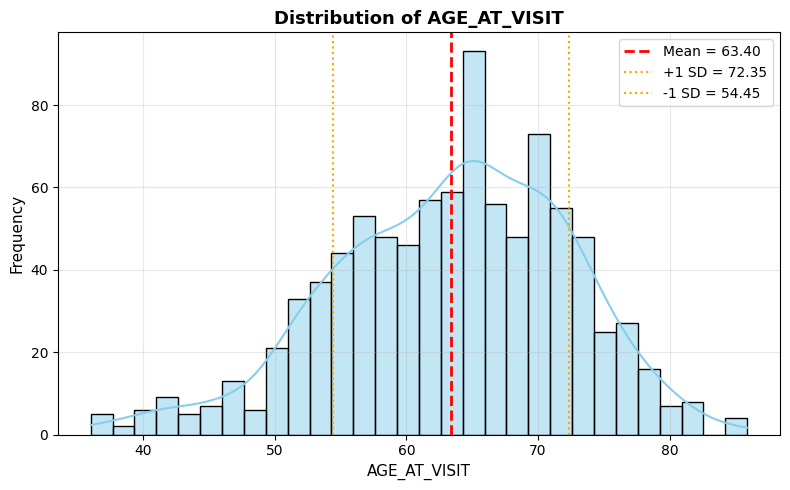

Statistical descriptors:
count    911.000000
mean      63.397036
std        8.951722
min       36.000000
25%       57.250000
50%       64.300000
75%       70.000000
max       85.900000
Name: AGE_AT_VISIT, dtype: float64


In [269]:
plot_hist_with_stats(subject_data,'AGE_AT_VISIT')

### SEX Analysis

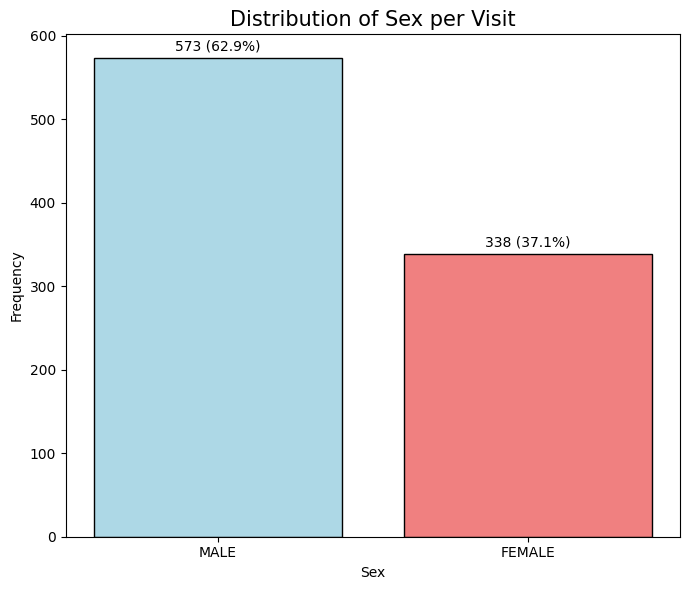

In [270]:
# distribucion datos de Sexo
sex_data_raw = subject_data['Sex of participant at birth'].replace({1:'MALE', 0:'FEMALE'})
counts_raw = sex_data_raw.value_counts()
total_raw = counts_raw.sum()

color_map = {'MALE': 'lightblue', 'FEMALE': 'lightcoral'}
fig, ax = plt.subplots(figsize=(7,6))

# Crear gráfico de barras
ax.bar(counts_raw.index, counts_raw.values, 
       color=[color_map[x] for x in counts_raw.index], edgecolor='black')

ax.set_title("Distribution of Sex per Visit", fontsize=15)
ax.set_ylabel("Frequency")
ax.set_xlabel("Sex")

# Añadir valores + porcentajes
for i, sex in enumerate(counts_raw.index):
    v = counts_raw[sex]
    pct = v / total_raw * 100
    ax.text(i, v + total_raw * 0.01, f"{v} ({pct:.1f}%)", ha='center')

plt.tight_layout()
plt.show()
men_patno=subject_data.loc[subject_data['Sex of participant at birth']==1,'PATNO'].unique().tolist()


### Mutation presence

In [271]:
mutation_data=subject_data[['PATNO','Visit ID','Parkin Mutation at Enrollment',
       'LRRK2 Mutation at Enrollment', 'SNCA Mutation at Enrollment',
       'GBA Mutation at Enrollment']].copy()


# Has a genetic mutation col 
mutation_data['Has a genetic mutation'] = mutation_data[['Parkin Mutation at Enrollment',
       'LRRK2 Mutation at Enrollment', 'SNCA Mutation at Enrollment',
       'GBA Mutation at Enrollment']].sum(axis=1)
       
mutation_data['Has a genetic mutation'] = mutation_data['Has a genetic mutation'].apply(lambda x: 1 if x>0 else 0)

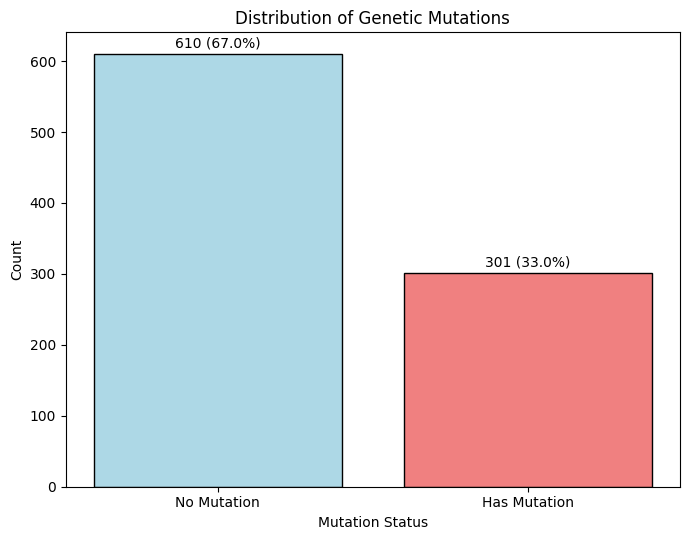

In [272]:
# --- 1. Conteo general ---
mutation_counts = mutation_data['Has a genetic mutation'].value_counts()
total = mutation_counts.sum()

# ---- Helper: asegurar que existan ambas categorías ----
def get_counts(counts):
    return [counts.get(0, 0), counts.get(1, 0)]

# Valores y colores consistentes
labels = ['No Mutation', 'Has Mutation']
colors = ['lightblue', 'lightcoral']

# --- Crear figura ---
fig, ax = plt.subplots(figsize=(7, 5.5))

# ---- Plot único: Todos los registros ----
vals = get_counts(mutation_counts)
ax.bar([0, 1], vals, color=colors, edgecolor='black')
ax.set_title('Distribution of Genetic Mutations')
ax.set_xlabel('Mutation Status')
ax.set_ylabel('Count')
ax.set_xticks([0,1])
ax.set_xticklabels(labels)

# Añadir textos (conteo + %)
for i, v in enumerate(vals):
    pct = v / total * 100
    ax.text(i, v + (total * 0.01), f'{v} ({pct:.1f}%)', ha='center')

plt.tight_layout()
plt.show()

In [273]:
has_mutation_data=mutation_data.loc[mutation_data['Has a genetic mutation']==1]
print(f'Number of records with mutation (per visit): {has_mutation_data.shape[0]}')

# function nueva columna
mutation_map = {
    'Parkin Mutation at Enrollment': 'Parkin',
    'LRRK2 Mutation at Enrollment': 'LRRK2',
    'SNCA Mutation at Enrollment': 'SNCA',
    'GBA Mutation at Enrollment': 'GBA'
}

# Función para construir el string de mutaciones
def get_mutation_list(row):
    muts = [name for col, name in mutation_map.items() if row[col] == 1]
    if len(muts) == 0:
        return "None"
    else:
        return " + ".join(muts)

# Crear nueva columna
has_mutation_data["Mutation List"] = has_mutation_data.apply(get_mutation_list, axis=1)

Number of records with mutation (per visit): 301


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_27348/667075376.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  has_mutation_data["Mutation List"] = has_mutation_data.apply(get_mutation_list, axis=1)


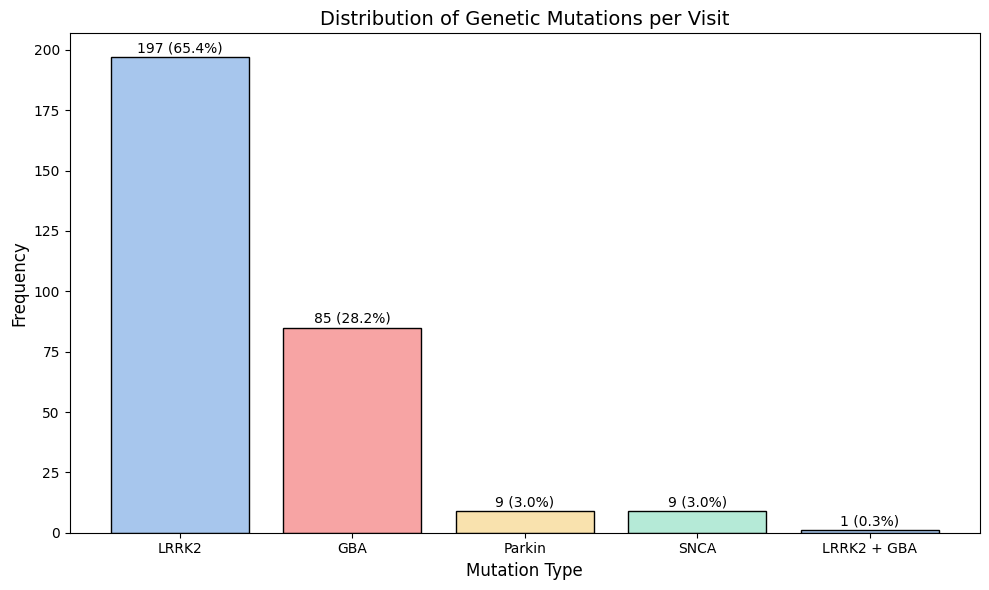

In [274]:
def compute_raw_counts(df):
    return df['Mutation List'].value_counts().sort_values(ascending=False)

# --- 1) FULL DATASET ---
grouped_counts_full = compute_raw_counts(has_mutation_data)

colors = ['#A7C6ED', '#F7A4A4', '#F9E2AE', '#B5EAD7']

# --- Create SINGLE PLOT ---
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    grouped_counts_full.index,
    grouped_counts_full.values,
    color=colors * (len(grouped_counts_full) // len(colors) + 1),
    edgecolor='black'
)

# Añadir valores y porcentajes
for i, (label, count) in enumerate(grouped_counts_full.items()):
    pct = count / grouped_counts_full.sum() * 100
    ax.text(
        i,
        count + max(grouped_counts_full.values)*0.01,
        f"{count} ({pct:.1f}%)",
        ha='center',
        fontsize=10
    )

ax.set_title("Distribution of Genetic Mutations per Visit", fontsize=14)
ax.set_ylabel("Frequency", fontsize=12)
ax.set_xlabel("Mutation Type", fontsize=12)

plt.tight_layout()
plt.show()


### Birth Year analysis

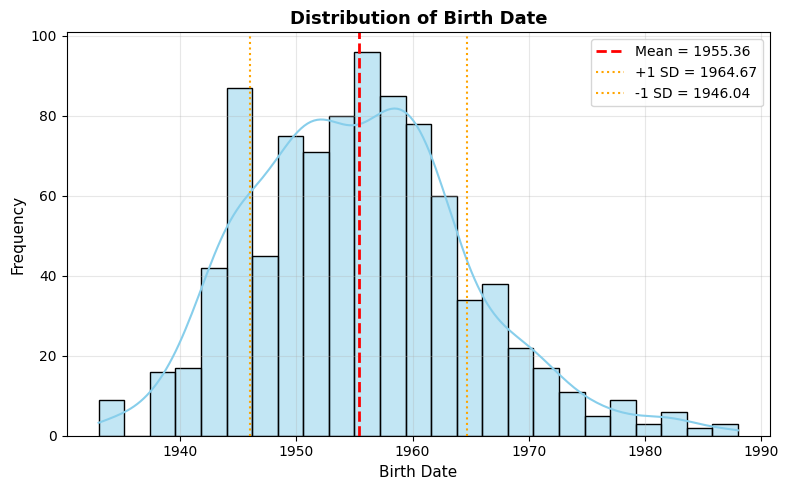

Statistical descriptors:
count     911.000000
mean     1955.356751
std         9.312113
min      1933.000000
25%      1949.000000
50%      1955.000000
75%      1961.000000
max      1988.000000
Name: Birth Date, dtype: float64


In [275]:
plot_hist_with_stats(subject_data,'Birth Date', bins=25)

=== Descriptive Statistics of Education Years ===
count    911.000000
mean      16.069155
std        3.634790
min        0.000000
25%       14.000000
50%       16.000000
75%       18.000000
max       28.000000
Name: Education_Years, dtype: float64


/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_27348/2994917845.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  edu_data['Education_Years'] = edu_data['Education_Years'].astype(int)


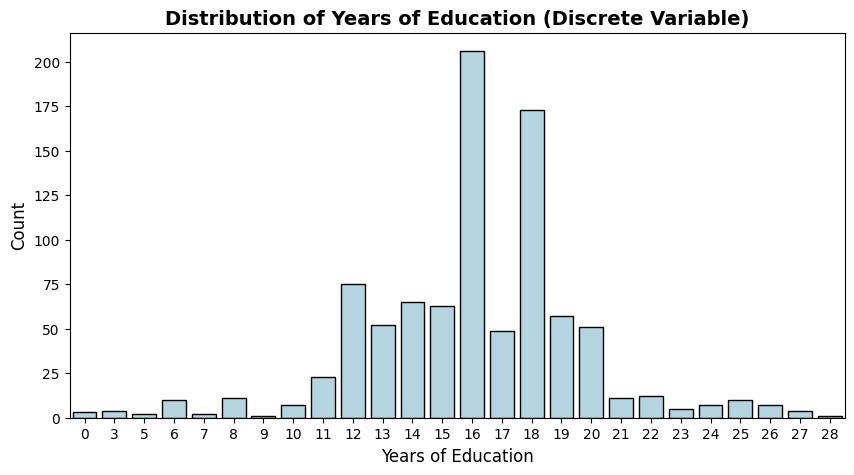

In [276]:
# Dataset for plotting
edu_data = subject_data[['Education_Years']]

# Convert to integer if needed
edu_data['Education_Years'] = edu_data['Education_Years'].astype(int)

# Frequency table
edu_counts = edu_data['Education_Years'].value_counts().sort_index()

# Bar plot
plt.figure(figsize=(10,5))
sns.barplot(
    x=edu_counts.index,
    y=edu_counts.values,
    color='lightblue',
    edgecolor='black'
)

# Labels
plt.title('Distribution of Years of Education (Discrete Variable)', fontsize=14, fontweight='bold')
plt.xlabel('Years of Education', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Descriptive statistics
print("=== Descriptive Statistics of Education Years ===")
print(edu_data['Education_Years'].describe())


### RACE Analysis

In [277]:
race_data=subject_data[[
    'Identify self as Asian',
    'Identify self as Black/African American',
    'Identify self as Hawaiian/Other Pacific Islander',
    'Identify self as American Indian/Alaska Native',
    'Identify self as White']].copy()



# function nueva columna
race_map = {
    'Identify self as Asian': 'Asian',
    'Identify self as Black/African American': 'Black/African American',
    'Identify self as Hawaiian/Other Pacific Islander': 'Hawaiian/Other Pacific Islander',
    'Identify self as American Indian/Alaska Native': 'American Indian/Alaska Native',
    'Identify self as White': 'White'
}

# Función para construir el string de mutaciones
def get_race_list(row):
    muts = [name for col, name in race_map.items() if row[col] == 1]
    if len(muts) == 0:
        return "None"
    else:
        return " + ".join(muts)


race_data["Race List"] = race_data.apply(get_race_list, axis=1)

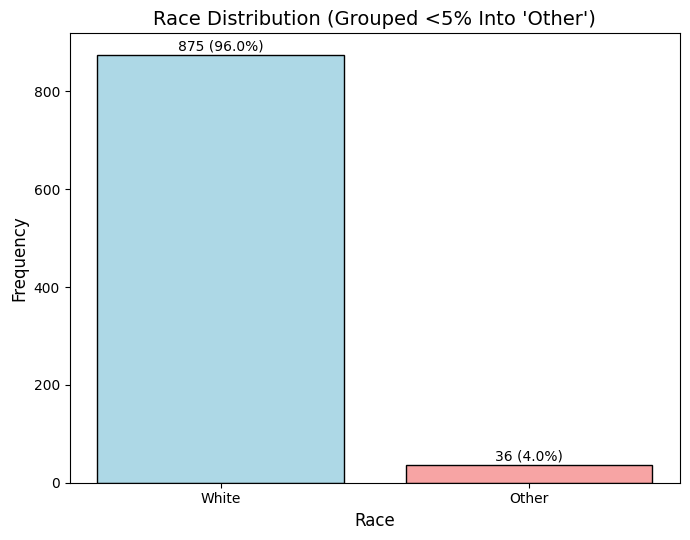

In [278]:
def compute_race_counts(df, threshold=0.05):

    # Conteos originales
    counts = df['Race List'].value_counts()

    total = counts.sum()

    # Identificar categorías por debajo del umbral
    small_categories = counts[counts / total < threshold].index

    # Reemplazar esas categorías por "Other"
    df_mod = df.copy()
    df_mod['Race List'] = df_mod['Race List'].replace(dict.fromkeys(small_categories, 'Other'))

    # Recalcular conteos después de agrupar
    counts_grouped = df_mod['Race List'].value_counts().sort_values(ascending=False)

    return counts_grouped


# --- 1) FULL DATASET ---
grouped_counts_full = compute_race_counts(race_data, threshold=0.05)

colors = ['lightblue', '#F7A4A4', '#F9E2AE', '#B5EAD7']

# --- Create SINGLE PLOT ---
fig, ax = plt.subplots(figsize=(7, 5.5))

bars = ax.bar(
    grouped_counts_full.index,
    grouped_counts_full.values,
    color=colors * (len(grouped_counts_full) // len(colors) + 1),
    edgecolor='black'
)

# Add counts and percentages
total = grouped_counts_full.sum()

for i, (label, count) in enumerate(grouped_counts_full.items()):
    pct = count / total * 100
    ax.text(
        i,
        count + max(grouped_counts_full.values)*0.01,
        f"{count} ({pct:.1f}%)",
        ha='center',
        fontsize=10
    )

# Formatting
ax.set_title("Race Distribution (Grouped <5% Into 'Other')", fontsize=14)
ax.set_ylabel("Frequency", fontsize=12)
ax.set_xlabel("Race", fontsize=12)

plt.tight_layout()
plt.show()



## VITAL DATA

In [279]:
vital_data=subject_data[["BMI","Delta_SBP","Delta_DBP","Delta_HR","Ortostatic_Hypotension","Standing BP - systolic (mmHg)",  "Supine BP - systolic (mmHg)", "Standing BP - diastolic (mmHg)","Supine BP - diastolic (mmHg)", "Standing heart rate (bpm)","Supine heart rate (bpm)"]]


### BMI

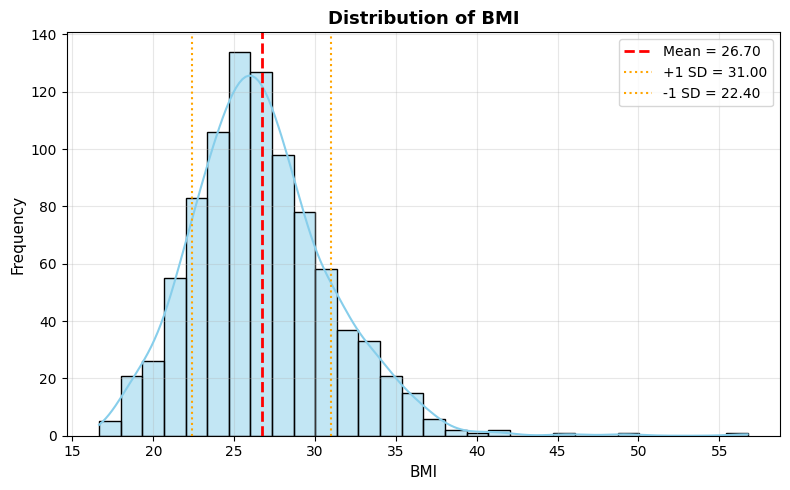

Statistical descriptors:
count    911.000000
mean      26.698888
std        4.303649
min       16.649324
25%       23.889463
50%       26.350164
75%       29.009709
max       56.752530
Name: BMI, dtype: float64


In [280]:
# Dataset para graficar
plot_hist_with_stats(vital_data,'BMI')

### Ortostatic Hypotension

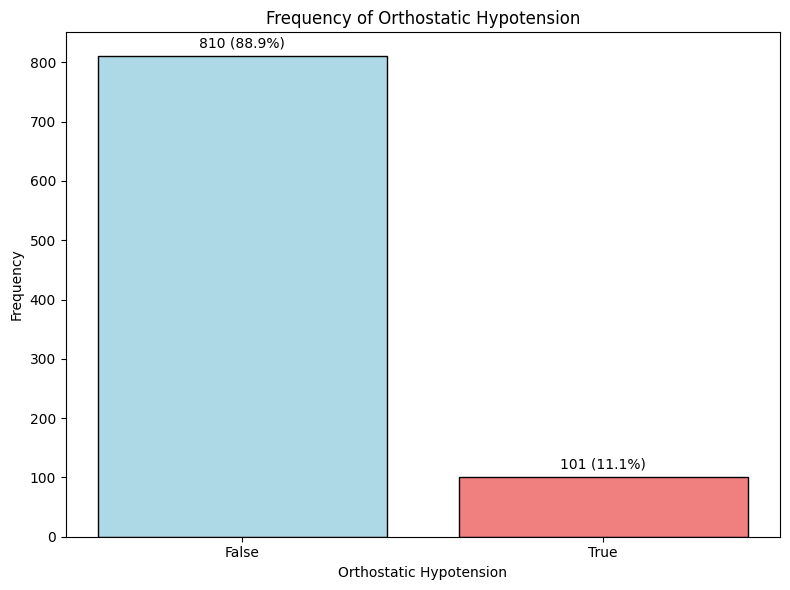

In [281]:

counts = vital_data["Ortostatic_Hypotension"].value_counts()
total = counts.sum()

# Create barplot
plt.figure(figsize=(8,6))
colors = ["lightblue", "lightcoral"]  # apply colors

bars = plt.bar(counts.index.astype(str), counts.values, 
               color=colors[:len(counts)], edgecolor='black')

plt.xlabel("Orthostatic Hypotension")
plt.ylabel("Frequency")
plt.title("Frequency of Orthostatic Hypotension")

# Add labels with count + percentage
for bar, value in zip(bars, counts.values):
    height = bar.get_height()
    pct = (value / total) * 100
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + total * 0.01,  # small space above
        f"{value} ({pct:.1f}%)",
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()



### BP Pressure

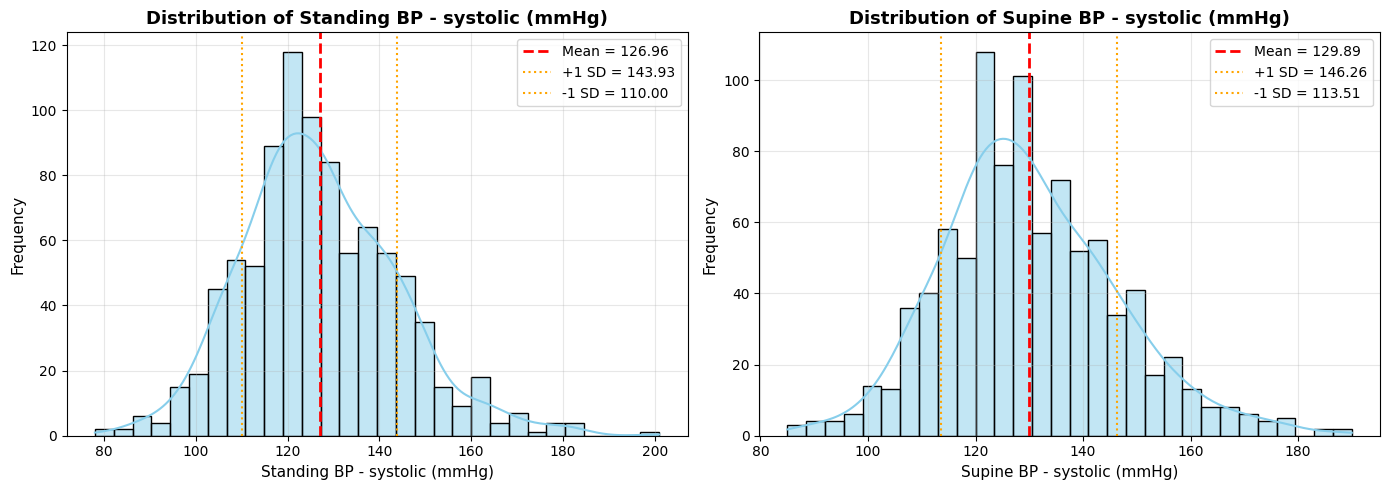

In [282]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_hist_subplots(axes[0], vital_data, "Standing BP - systolic (mmHg)")
plot_hist_subplots(axes[1], vital_data, "Supine BP - systolic (mmHg)")

plt.tight_layout()
plt.show()

#### Systolic BP

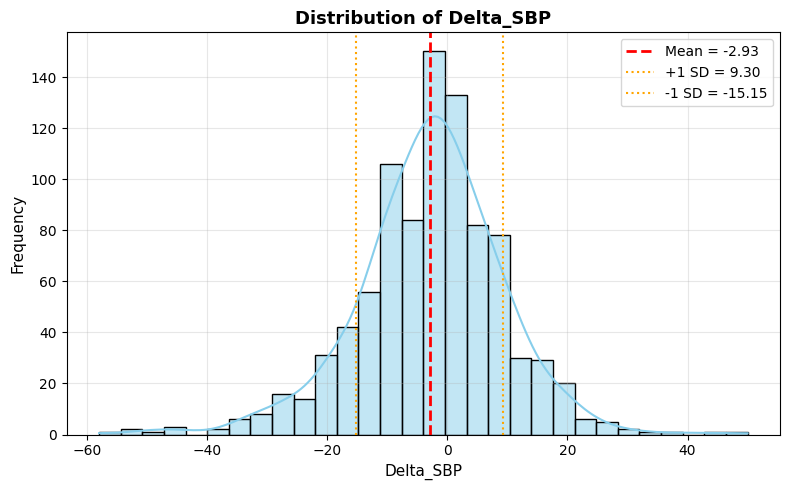

Statistical descriptors:
count    911.000000
mean      -2.926022
std       12.227482
min      -58.000000
25%      -10.000000
50%       -2.000000
75%        5.000000
max       50.000000
Name: Delta_SBP, dtype: float64


In [283]:
# Dataset para graficar
plot_hist_with_stats(vital_data,"Delta_SBP")

#### Diastolic BP

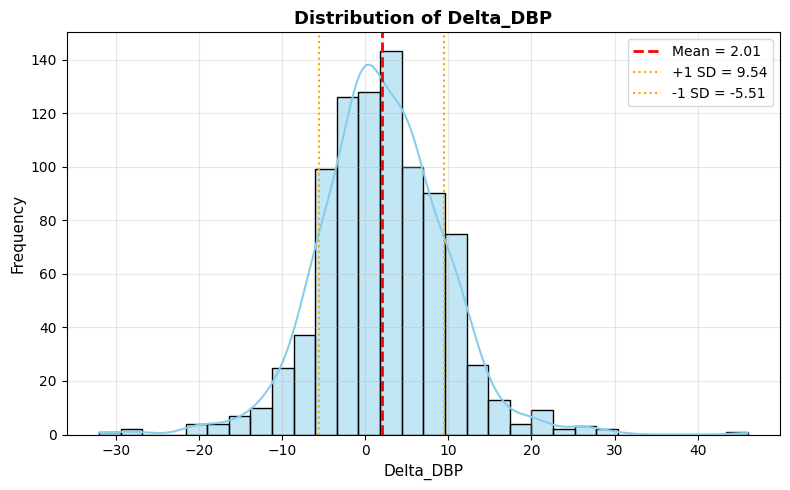

Statistical descriptors:
count    911.000000
mean       2.014832
std        7.521779
min      -32.000000
25%       -2.000000
50%        2.000000
75%        6.000000
max       46.000000
Name: Delta_DBP, dtype: float64


In [284]:
plot_hist_with_stats(vital_data,"Delta_DBP")

In [285]:
def clasificar_updrs_thresholds(df):
    df = df.copy()

    # Diccionario de puntos de corte oficiales por Parte
    thresholds = {
        'I': (10, 21),   # <=10 leve, 11-21 moderado, >=22 severo
        'II': (12, 29),  # <=12 leve, 13-29 moderado, >=30 severo
        'III': (32, 58), # <=32 leve, 33-58 moderado, >=59 severo
        'IV': (4, 12)    # <=4 leve, 5-12 moderado, >=13 severo
    }

    # Mapeo de columnas del dataframe
    columnas = {
        'I': 'MDS-UPDRS Part I (Patient Questionnaire) Total Score',
        'II': 'MDS-UPDRS Part II Total Score',
        'III': 'MDS-UPDRS Part III Total Score',
        'IV': 'MDS-UPDRS Part IV Total Score'
    }

    # Función para clasificar según thresholds
    def clasificar(valor, parte):
        t1, t2 = thresholds[parte]

        if valor <= t1:
            return 'Mild'
        elif valor <= t2:
            return 'Moderate'
        else:
            return 'Moderate' #deberia ser severe pero por balance lo dejo en moderado 

    # Aplicar clasificación por parte
    for parte, col in columnas.items():
        df[f'UPDRS_{parte}_Class'] = df[col].apply(lambda x: clasificar(x, parte))

    return df

# 4 types of progression based MCID
def categorize_progression(delta, T1, T2):
    if delta <= T1:
        return 'Substantial improv.' 
    elif T1 < delta <= T2:
        return 'No significant change.'  
    else:
        return 'Substantial progress.'


In [286]:
# Aplicar la clasificación al dataframe

subject_data = clasificar_updrs_thresholds(subject_data)
subject_data['UPDRS_I_ProgressionType'] = subject_data['Δ UPDRS_I_1Y'].apply(lambda delta: categorize_progression(delta, -3,3 ))
subject_data['UPDRS_II_ProgressionType'] = subject_data['Δ UPDRS_II_1Y'].apply(lambda delta: categorize_progression(delta, -3,5 ))
subject_data['UPDRS_III_ProgressionType'] = subject_data['Δ UPDRS_III_1Y'].apply(lambda delta: categorize_progression(delta, -3,5 ))
subject_data.head(3)

,PATNO,Visit ID,MDS-UPDRS Part I (Patient Questionnaire) Total Score,MDS-UPDRS Part II Total Score,MDS-UPDRS Part III Total Score,MDS-UPDRS Part IV Total Score,Height (cm),Weight (kg),Temperature (Celsius),Supine BP - systolic (mmHg),...,Delta_DBP,Delta_HR,Ortostatic_Hypotension,UPDRS_I_Class,UPDRS_II_Class,UPDRS_III_Class,UPDRS_IV_Class,UPDRS_I_ProgressionType,UPDRS_II_ProgressionType,UPDRS_III_ProgressionType
0,100006,V04_V06,8,9.0,17,2.0,180.0,115.0,36.6,131.0,...,0.0,10.0,False,Mild,Mild,Mild,Mild,Substantial progress.,Substantial improv.,Substantial improv.
1,100007,V04_V06,2,7.0,23,0.0,172.0,68.0,36.3,128.0,...,18.0,-3.0,False,Mild,Mild,Mild,Mild,No significant change.,Substantial improv.,Substantial improv.
2,100012,V04_V06,6,5.0,14,0.0,159.0,78.7,36.4,132.0,...,-9.0,5.0,False,Mild,Mild,Mild,Mild,No significant change.,No significant change.,No significant change.


In [287]:
subject_data.to_csv('/Users/fserracrespi/Desktop/PD_Project_UofL/PD_DATA/MODELS DEVELOPMENT/DATA FOR MODELS/Subject_Data.csv', index=False)

## MOTOR DATA

In [288]:
motor_data = pd.read_csv('/Users/fserracrespi/Desktop/PD_Project_UofL/PD_DATA/PD_1y_progress_DATA/Data_Motor_1Year_12SEP2025.csv')
motor_data.drop(columns=['Unnamed: 0','Is the participant on medication or receiving deep brain stimulation for treating the symptoms of Parkinsons disease?',
                            'Is subject on medication for PD'],inplace=True)
motor_data.sort_values(by=['PATNO','Visit ID'],inplace=True)
motor_data.head(3)

,PATNO,Visit ID,MDS-UPDRS Part I (Patient Questionnaire) Total Score,MDS-UPDRS Part II Total Score,Does participant have DBS,MDS-UPDRS Part III Total Score,3.21 HOEHN AND YAHR STAGE,MDS-UPDRS Part IV Total Score,DBS_Transition_Visit,DBS_Post_Transition,SCHWAB & ENGLAND ADL,MDS-UPDRS Total Score 1YearProg,UPDRS_III_1YearProg,MDS-UPDRS Total Score,Δ TOTAL_UPDRS_1Y,Δ UPDRS_I_1Y,Δ UPDRS_II_1Y,Δ UPDRS_III_1Y,Δ UPDRS_IV_1Y
728,3001,V10_V12,6,5.0,0,35,2,0.0,False,0.0,90,37.0,26,46.0,-9.0,1,-1.0,-9,0.0
729,3003,V10_V12,9,10.0,0,53,3,0.0,False,0.0,85,59.0,39,72.0,-13.0,2,-1.0,-14,0.0
730,3010,V10_V12,11,16.0,0,18,2,7.0,False,0.0,80,70.0,34,52.0,18.0,0,4.0,16,-2.0


In [289]:
# Aplicar la clasificación al dataframe

motor_data = clasificar_updrs_thresholds(motor_data)
motor_data['UPDRS_I_ProgressionType'] = motor_data['Δ UPDRS_I_1Y'].apply(lambda delta: categorize_progression(delta, -3,3 ))
motor_data['UPDRS_II_ProgressionType'] = motor_data['Δ UPDRS_II_1Y'].apply(lambda delta: categorize_progression(delta, -3,5 ))
motor_data['UPDRS_III_ProgressionType'] = motor_data['Δ UPDRS_III_1Y'].apply(lambda delta: categorize_progression(delta, -3,5 ))
motor_data.head(3)

,PATNO,Visit ID,MDS-UPDRS Part I (Patient Questionnaire) Total Score,MDS-UPDRS Part II Total Score,Does participant have DBS,MDS-UPDRS Part III Total Score,3.21 HOEHN AND YAHR STAGE,MDS-UPDRS Part IV Total Score,DBS_Transition_Visit,DBS_Post_Transition,...,Δ UPDRS_II_1Y,Δ UPDRS_III_1Y,Δ UPDRS_IV_1Y,UPDRS_I_Class,UPDRS_II_Class,UPDRS_III_Class,UPDRS_IV_Class,UPDRS_I_ProgressionType,UPDRS_II_ProgressionType,UPDRS_III_ProgressionType
728,3001,V10_V12,6,5.0,0,35,2,0.0,False,0.0,...,-1.0,-9,0.0,Mild,Mild,Moderate,Mild,No significant change.,No significant change.,Substantial improv.
729,3003,V10_V12,9,10.0,0,53,3,0.0,False,0.0,...,-1.0,-14,0.0,Mild,Mild,Moderate,Mild,No significant change.,No significant change.,Substantial improv.
730,3010,V10_V12,11,16.0,0,18,2,7.0,False,0.0,...,4.0,16,-2.0,Moderate,Moderate,Mild,Moderate,No significant change.,No significant change.,Substantial progress.


In [290]:
motor_data.to_csv('/Users/fserracrespi/Desktop/PD_Project_UofL/PD_DATA/MODELS DEVELOPMENT/DATA FOR MODELS/Motor_Data.csv', index=False)

### Motor Data Correlation Matrix

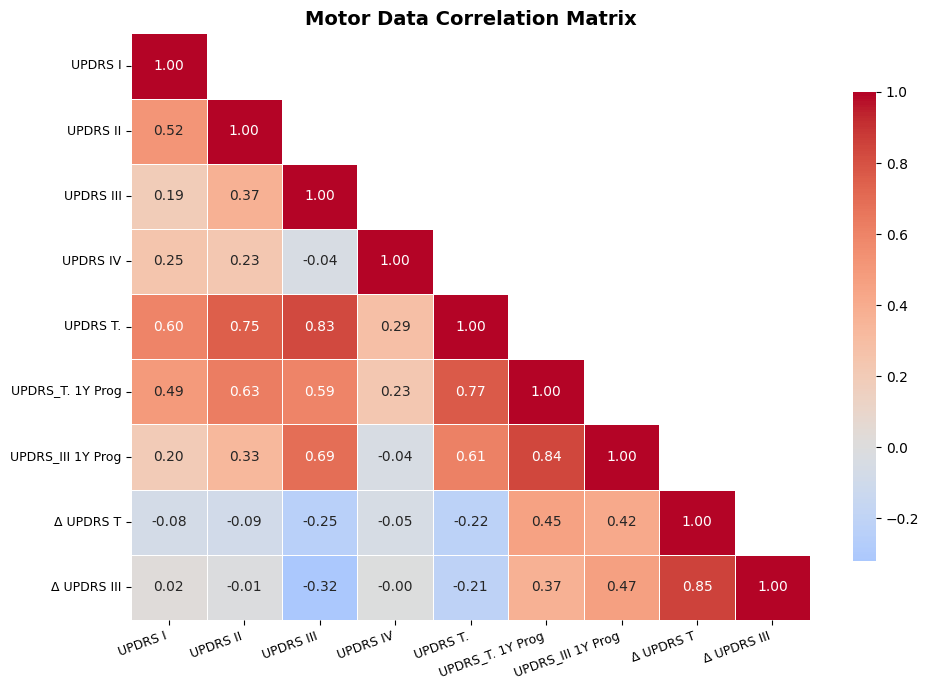

In [291]:
# Calcular la matriz de correlación
corr = motor_data[['MDS-UPDRS Part I (Patient Questionnaire) Total Score',
    'MDS-UPDRS Part II Total Score',
    'MDS-UPDRS Part III Total Score',
    'MDS-UPDRS Part IV Total Score',
    'MDS-UPDRS Total Score',
    'MDS-UPDRS Total Score 1YearProg',
    'UPDRS_III_1YearProg',
    'Δ TOTAL_UPDRS_1Y','Δ UPDRS_III_1Y',
    
]].corr()

# Renombrar columnas e índices (más corto y legible)
corr.columns = [
    'UPDRS I',
    'UPDRS II', 
    'UPDRS III',
    'UPDRS IV', 
    'UPDRS T.',
    'UPDRS_T. 1Y Prog',
    'UPDRS_III 1Y Prog', 
    'Δ UPDRS T',
    'Δ UPDRS III',

]
corr.index = corr.columns  # mantener consistencia filas/columnas

# Crear máscara para mostrar solo la mitad inferior (opcional)
mask = np.triu(np.ones_like(corr, dtype=bool),k=1)

# Crear el mapa de calor
plt.figure(figsize=(10, 7))
sns.heatmap(
    corr,
    mask=mask,               # elimina la mitad superior si lo prefieres
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Motor Data Correlation Matrix", fontsize=14, weight='bold')
plt.xticks(rotation=20, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

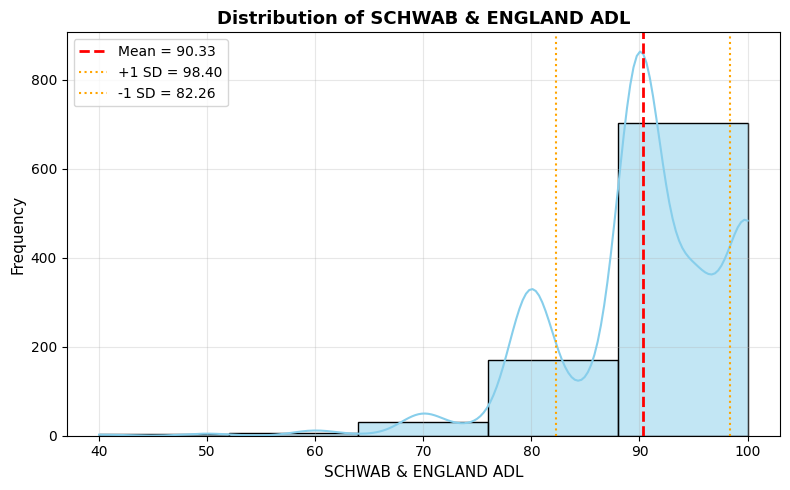

Statistical descriptors:
count    911.000000
mean      90.329308
std        8.069152
min       40.000000
25%       90.000000
50%       90.000000
75%       95.000000
max      100.000000
Name: SCHWAB & ENGLAND ADL, dtype: float64


In [292]:
plot_hist_with_stats(motor_data,  'SCHWAB & ENGLAND ADL', bins=5)

### UPDRS Distribution

#### UPDRS I

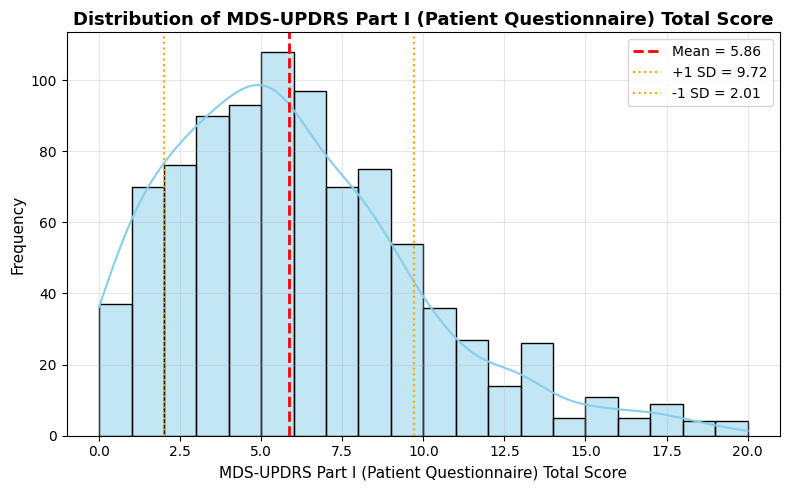

Statistical descriptors:
count    911.000000
mean       5.863886
std        3.856651
min        0.000000
25%        3.000000
50%        5.000000
75%        8.000000
max       20.000000
Name: MDS-UPDRS Part I (Patient Questionnaire) Total Score, dtype: float64


In [293]:
plot_hist_with_stats(motor_data,  'MDS-UPDRS Part I (Patient Questionnaire) Total Score',bins=20)

posx and posy should be finite values
posx and posy should be finite values


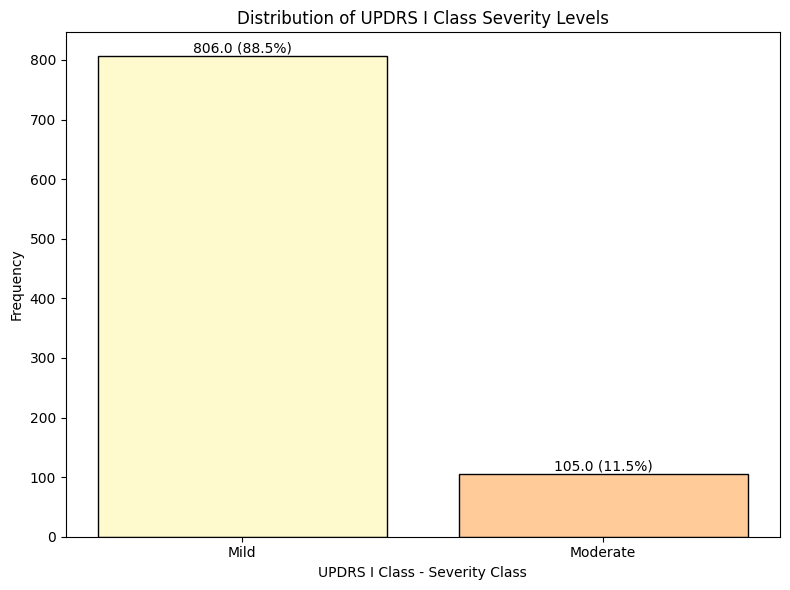

In [294]:
plot_updrs_severity(motor_data,'UPDRS_I_Class')


#### UPDRS II

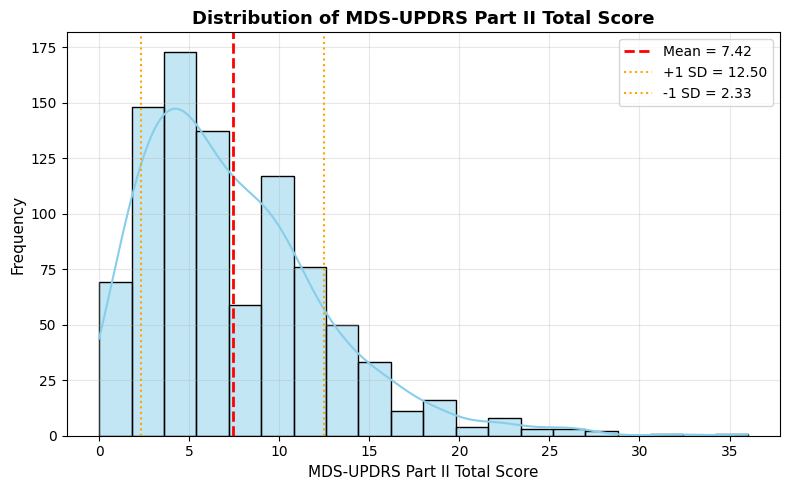

Statistical descriptors:
count    911.000000
mean       7.419319
std        5.084324
min        0.000000
25%        4.000000
50%        6.000000
75%       10.000000
max       36.000000
Name: MDS-UPDRS Part II Total Score, dtype: float64


In [295]:
plot_hist_with_stats(motor_data,  'MDS-UPDRS Part II Total Score',bins=20)

posx and posy should be finite values
posx and posy should be finite values


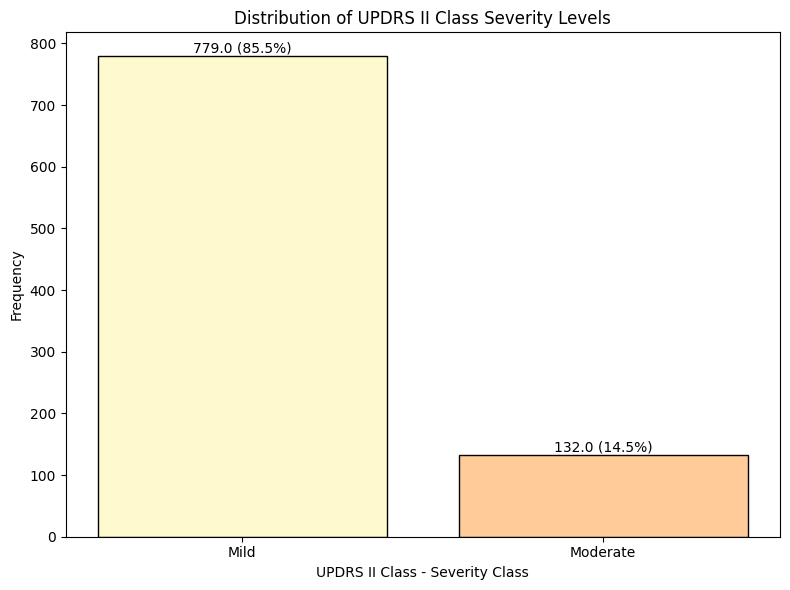

In [296]:
plot_updrs_severity(motor_data,'UPDRS_II_Class')


#### UPDRS III

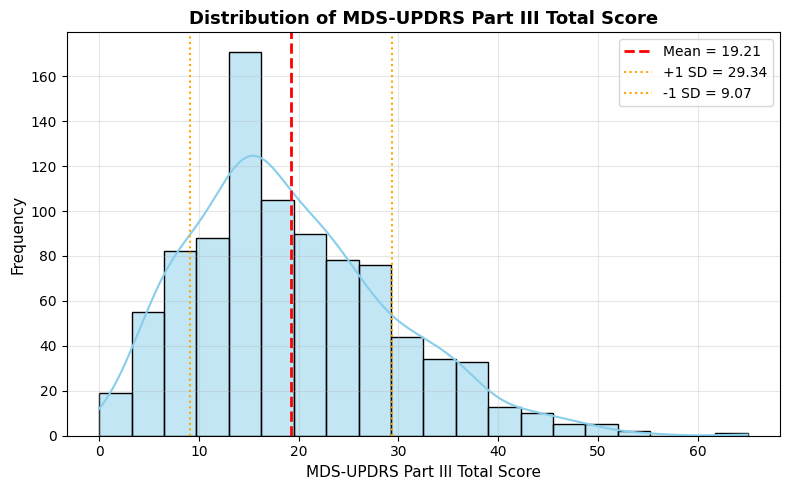

Statistical descriptors:
count    911.000000
mean      19.206367
std       10.133895
min        0.000000
25%       12.000000
50%       18.000000
75%       25.000000
max       65.000000
Name: MDS-UPDRS Part III Total Score, dtype: float64


In [297]:
plot_hist_with_stats(motor_data,  'MDS-UPDRS Part III Total Score',bins=20)

posx and posy should be finite values
posx and posy should be finite values


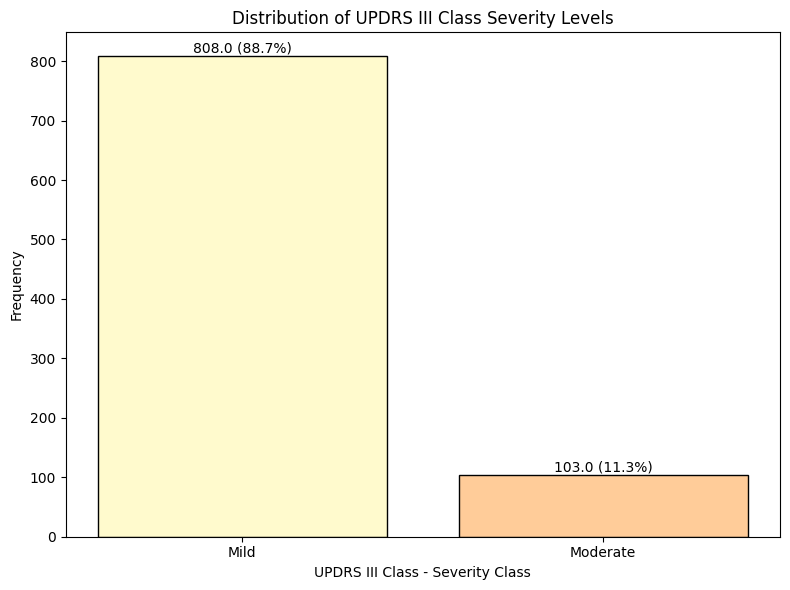

In [298]:
plot_updrs_severity(motor_data,'UPDRS_III_Class')

#### UPDRS IV

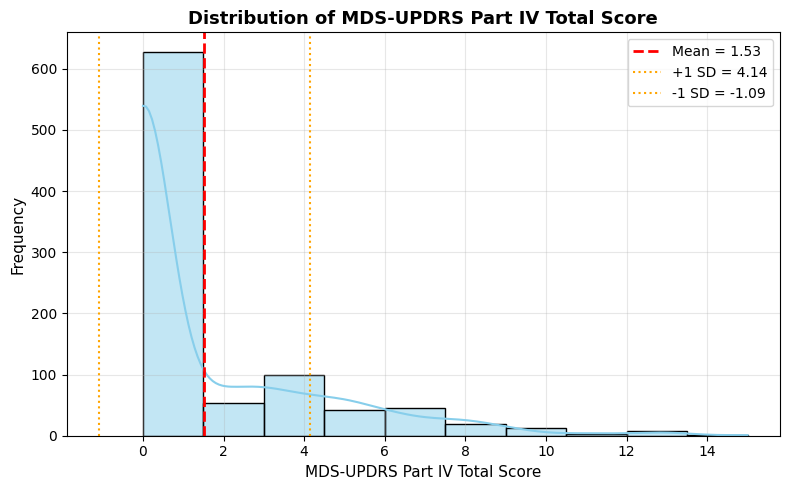

Statistical descriptors:
count    911.000000
mean       1.526894
std        2.614644
min        0.000000
25%        0.000000
50%        0.000000
75%        3.000000
max       15.000000
Name: MDS-UPDRS Part IV Total Score, dtype: float64


In [299]:
plot_hist_with_stats(motor_data,  'MDS-UPDRS Part IV Total Score',bins=10)

posx and posy should be finite values
posx and posy should be finite values


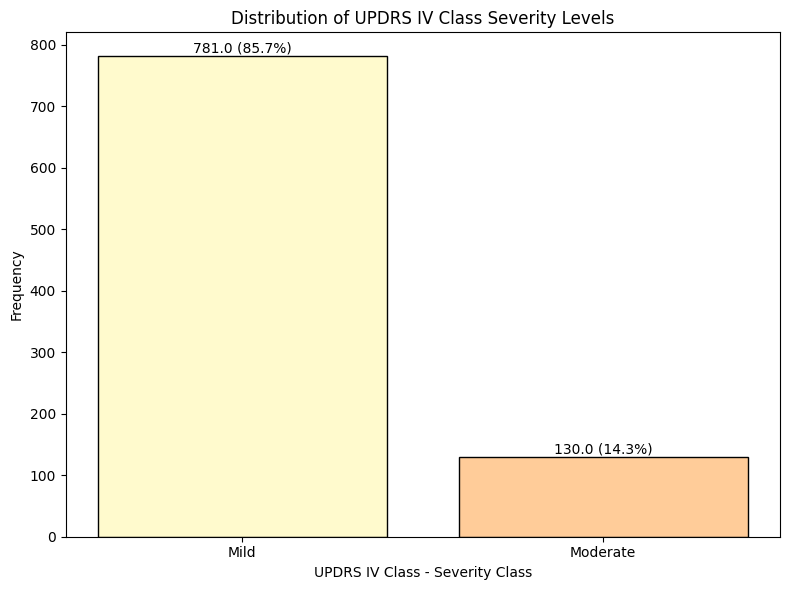

In [300]:
plot_updrs_severity(motor_data,'UPDRS_IV_Class')

#### UPDRS TOTAL

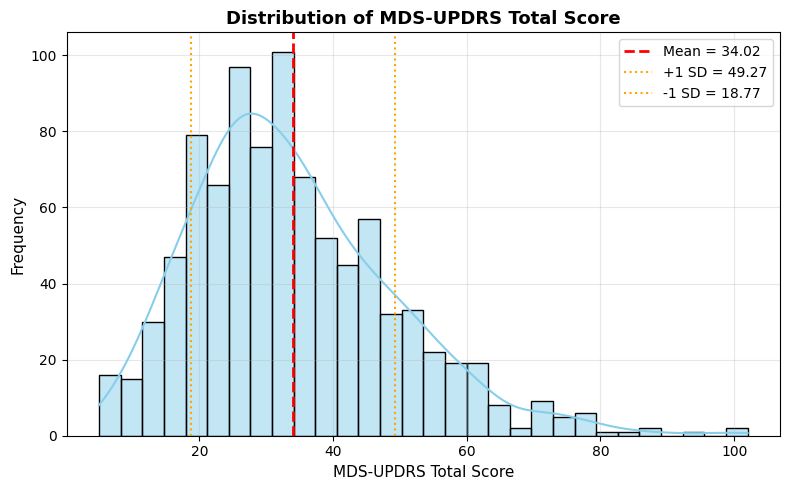

Statistical descriptors:
count    911.000000
mean      34.016465
std       15.250680
min        5.000000
25%       23.000000
50%       32.000000
75%       43.000000
max      102.000000
Name: MDS-UPDRS Total Score, dtype: float64


In [301]:
plot_hist_with_stats(motor_data,  "MDS-UPDRS Total Score")

#### UPDRS TOTAL Baseline vs UPDRS TOTAL Next Visit

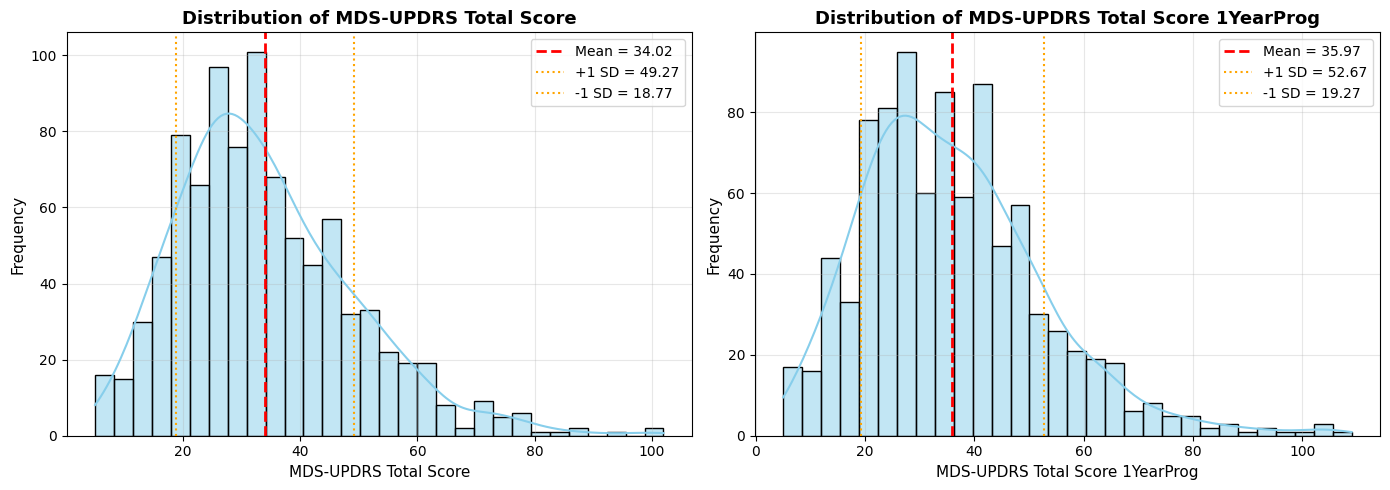

In [302]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_hist_subplots(axes[0], motor_data, "MDS-UPDRS Total Score")
plot_hist_subplots(axes[1], motor_data, "MDS-UPDRS Total Score 1YearProg")

plt.tight_layout()
plt.show()

### Δ UPDRS Distribution

#### Δ UPDRS Correlation

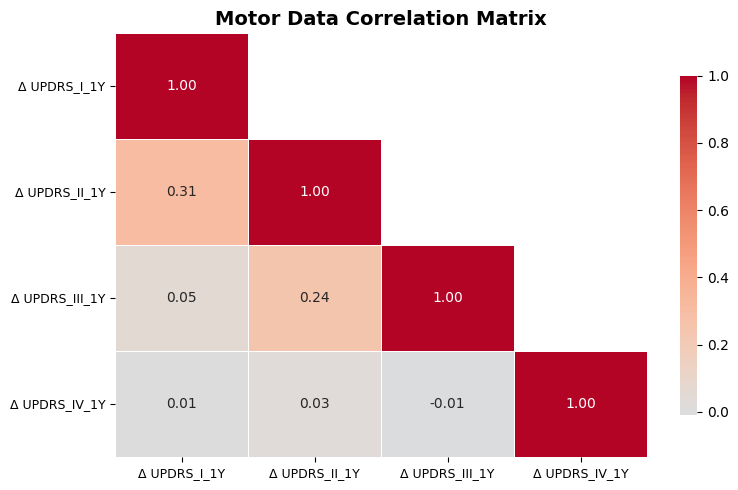

In [303]:
data_deltas = motor_data[['Δ UPDRS_I_1Y','Δ UPDRS_II_1Y','Δ UPDRS_III_1Y','Δ UPDRS_IV_1Y']].copy()
corr = data_deltas.corr()
# Crear máscara para mostrar solo la mitad inferior (opcional)
mask = np.triu(np.ones_like(corr, dtype=bool),k=1)

# Crear el mapa de calor
plt.figure(figsize=(8, 5))
sns.heatmap(
    corr,
    mask=mask,               # elimina la mitad superior si lo prefieres
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Motor Data Correlation Matrix", fontsize=14, weight='bold')
plt.xticks(rotation=0, ha='center', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

#### Δ UPDRS 1

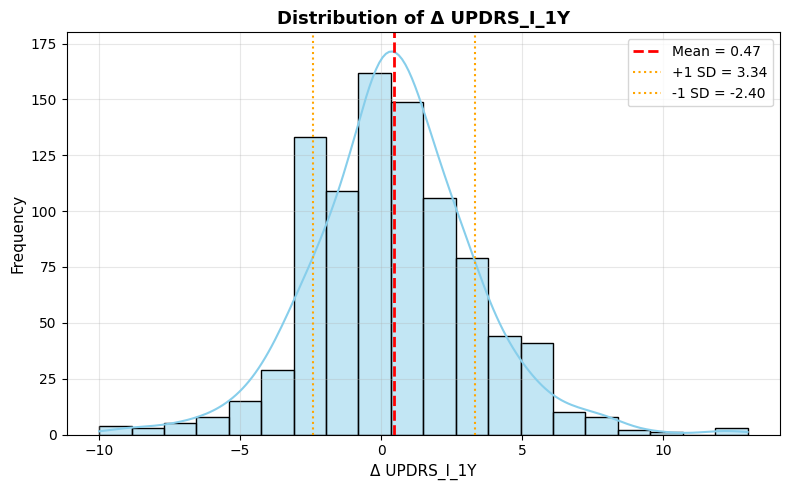

Statistical descriptors:
count    911.000000
mean       0.468716
std        2.872924
min      -10.000000
25%       -1.000000
50%        0.000000
75%        2.000000
max       13.000000
Name: Δ UPDRS_I_1Y, dtype: float64


In [304]:
plot_hist_with_stats(motor_data,'Δ UPDRS_I_1Y', bins=20)


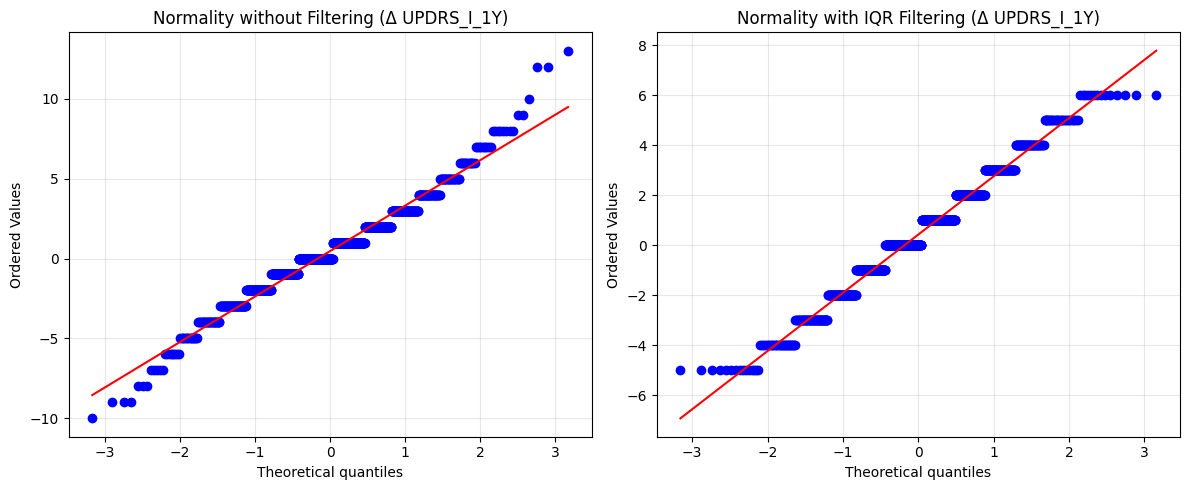

Original — χ²=34.627, p-value=0.0000
❌ Se rechaza normalidad

Filtrado — χ²=3.092, p-value=0.2131
✅ No se rechaza normalidad

-1.0 2.0 -5.5 6.5


In [305]:
qq_plot_with_iqr_filtering(motor_data,'Δ UPDRS_I_1Y')

In [306]:
# 4 types of progression based MCID
def categorize_progression(delta, T1, T2):
    if delta <= T1:
        return 'Substantial improv.' 
    elif T1 < delta <= T2:
        return 'No significant change.'  
    else:
        return 'Substantial progress.'

# Binary progression: Progression vs Improvement/No progress
def categorize_progression2(delta):
    if 0 < delta:
        return 'Progression.'
    else:
        return 'Improvement or no progress.'

In [307]:
motor_data['UPDRS_I_ProgressionType'] = motor_data['Δ UPDRS_I_1Y'].apply(lambda delta: categorize_progression(delta, -3,3 ))
motor_data['UPDRS_I_YNProgression'] = motor_data['Δ UPDRS_I_1Y'].apply(categorize_progression2)
print(motor_data['UPDRS_I_ProgressionType'].value_counts())
print(motor_data['UPDRS_I_YNProgression'].value_counts())

UPDRS_I_ProgressionType
No significant change.    683
Substantial improv.       119
Substantial progress.     109
Name: count, dtype: int64
UPDRS_I_YNProgression
Improvement or no progress.    468
Progression.                   443
Name: count, dtype: int64


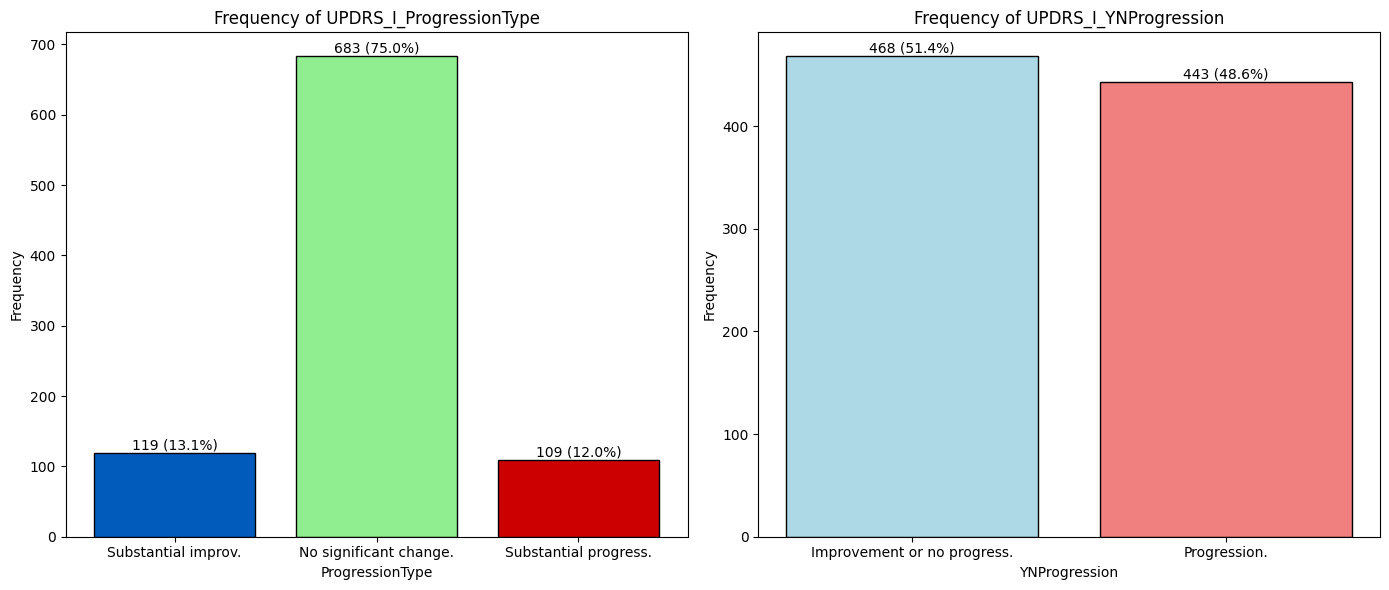

In [308]:
plot_updrs_progression_types(motor_data,col1pt="UPDRS_I_ProgressionType",col2yn="UPDRS_I_YNProgression")

#### Δ UPDRS 2

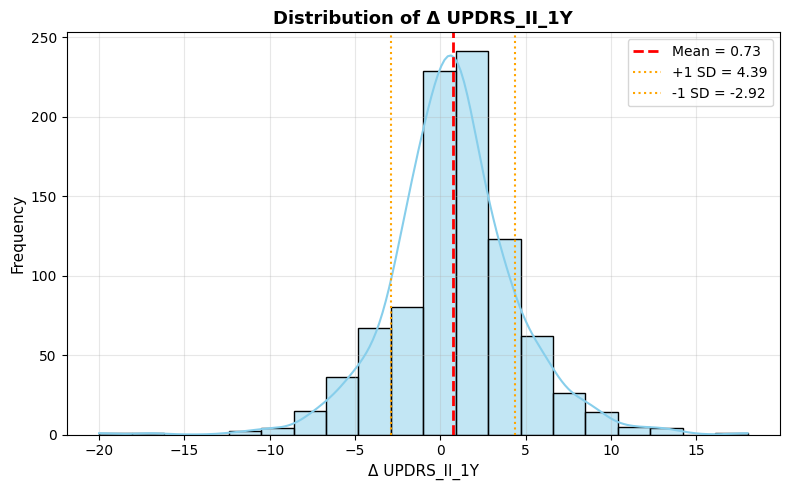

Statistical descriptors:
count    911.000000
mean       0.733260
std        3.655221
min      -20.000000
25%       -1.000000
50%        1.000000
75%        3.000000
max       18.000000
Name: Δ UPDRS_II_1Y, dtype: float64


In [309]:
plot_hist_with_stats(motor_data,'Δ UPDRS_II_1Y', bins=20)

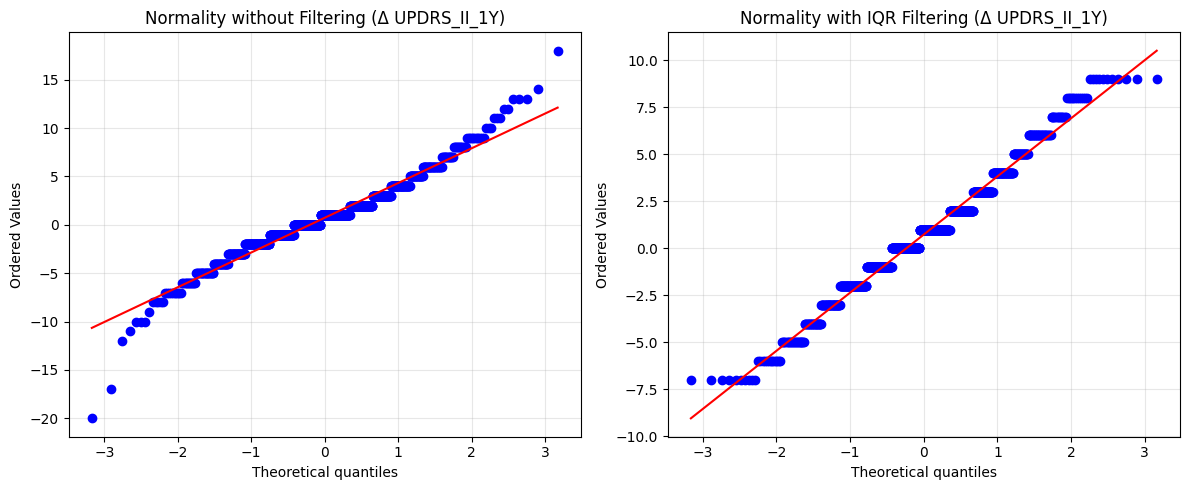

Original — χ²=65.455, p-value=0.0000
❌ Se rechaza normalidad

Filtrado — χ²=5.094, p-value=0.0783
✅ No se rechaza normalidad

-1.0 3.0 -7.0 9.0


In [310]:
qq_plot_with_iqr_filtering(motor_data,'Δ UPDRS_II_1Y')

In [311]:
motor_data['UPDRS_II_ProgressionType'] = motor_data['Δ UPDRS_II_1Y'].apply(lambda delta: categorize_progression(delta, -3,5 ))
motor_data['UPDRS_II_YNProgression'] = motor_data['Δ UPDRS_II_1Y'].apply(categorize_progression2)
print(motor_data['UPDRS_II_ProgressionType'].value_counts())
print(motor_data['UPDRS_II_YNProgression'].value_counts())

UPDRS_II_ProgressionType
No significant change.    703
Substantial improv.       126
Substantial progress.      82
Name: count, dtype: int64
UPDRS_II_YNProgression
Progression.                   476
Improvement or no progress.    435
Name: count, dtype: int64


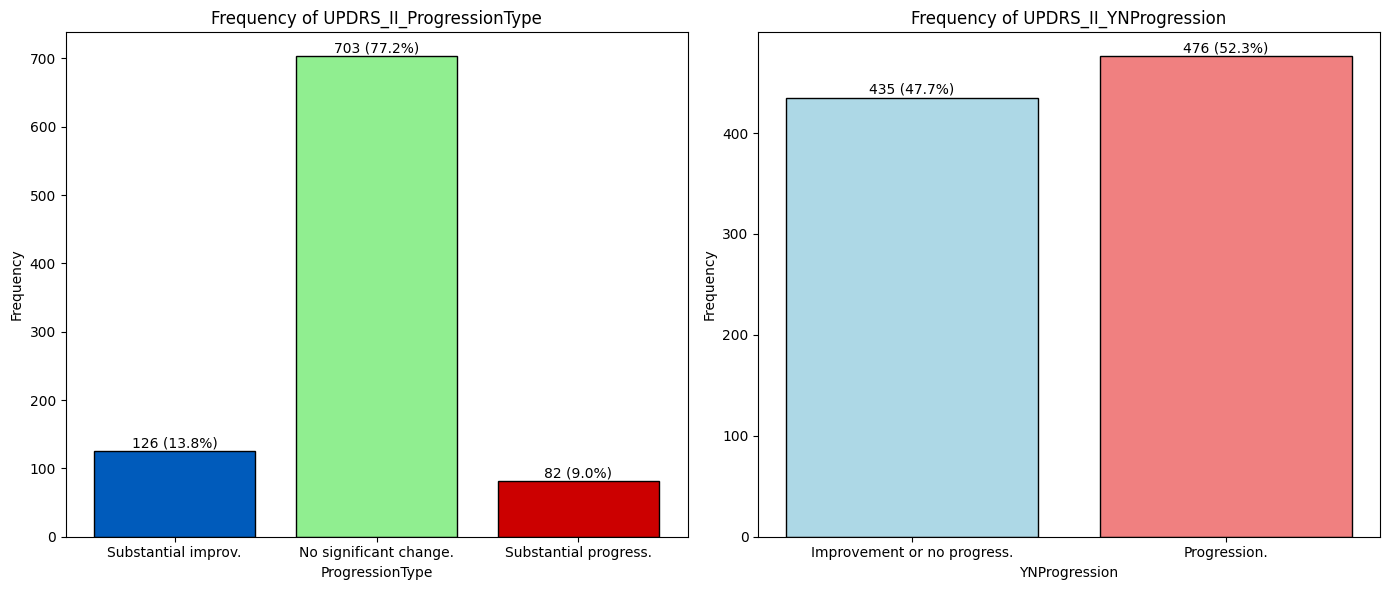

In [312]:
plot_updrs_progression_types(motor_data,col1pt="UPDRS_II_ProgressionType",col2yn="UPDRS_II_YNProgression")

#### Δ UPDRS 3

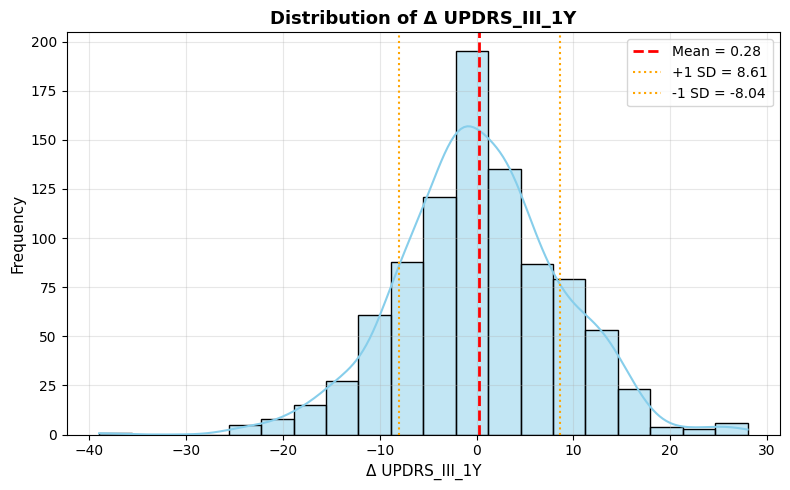

Statistical descriptors:
count    911.000000
mean       0.282108
std        8.324893
min      -39.000000
25%       -5.000000
50%        0.000000
75%        5.000000
max       28.000000
Name: Δ UPDRS_III_1Y, dtype: float64


In [313]:
plot_hist_with_stats(motor_data,'Δ UPDRS_III_1Y', bins=20)

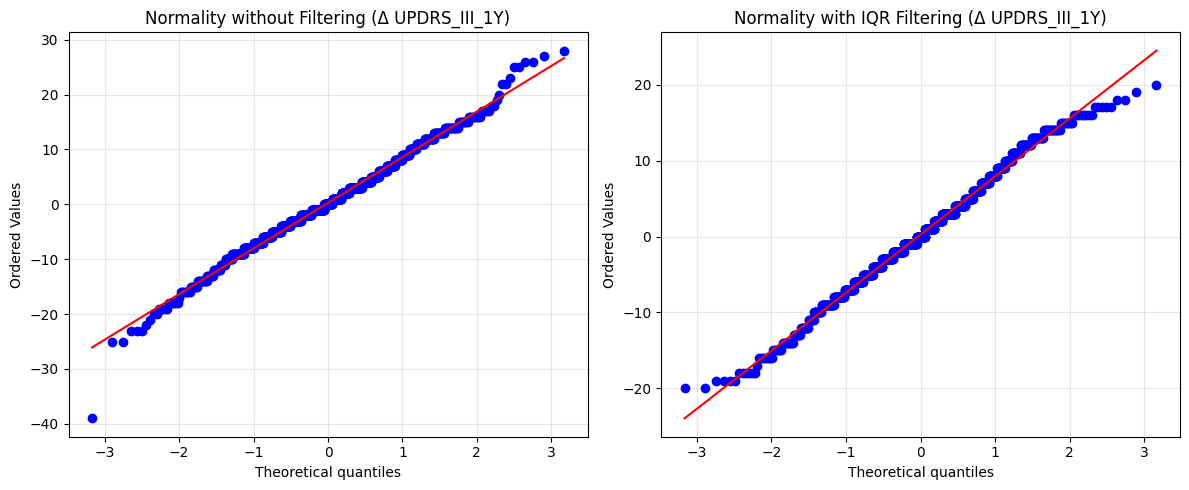

Original — χ²=12.833, p-value=0.0016
❌ Se rechaza normalidad

Filtrado — χ²=3.102, p-value=0.2120
✅ No se rechaza normalidad

-5.0 5.0 -20.0 20.0


In [314]:
qq_plot_with_iqr_filtering(motor_data,'Δ UPDRS_III_1Y')

In [315]:
motor_data['UPDRS_III_ProgressionType'] = motor_data['Δ UPDRS_III_1Y'].apply(lambda delta: categorize_progression(delta, -3,5 ))
motor_data['UPDRS_III_YNProgression'] = motor_data['Δ UPDRS_III_1Y'].apply(categorize_progression2)
print(motor_data['UPDRS_III_ProgressionType'].value_counts())
print(motor_data['UPDRS_III_YNProgression'].value_counts())

UPDRS_III_ProgressionType
No significant change.    360
Substantial improv.       326
Substantial progress.     225
Name: count, dtype: int64
UPDRS_III_YNProgression
Improvement or no progress.    477
Progression.                   434
Name: count, dtype: int64


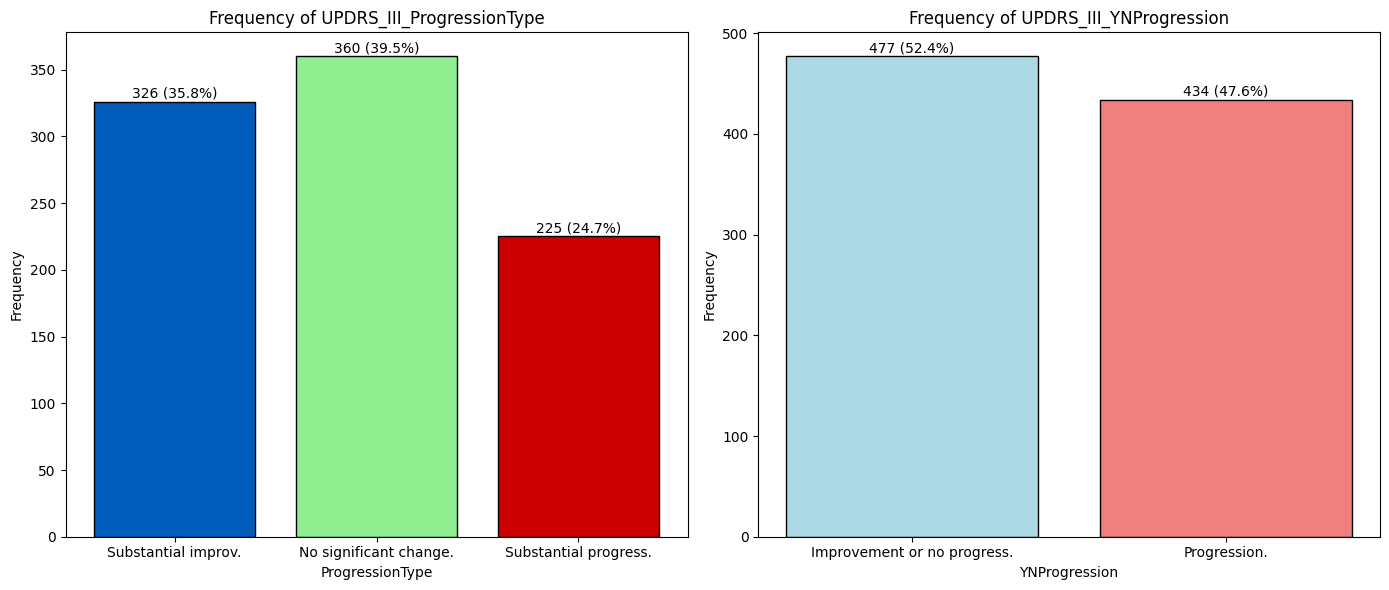

In [316]:
plot_updrs_progression_types(motor_data,col1pt="UPDRS_III_ProgressionType",col2yn="UPDRS_III_YNProgression")

#### Δ UPDRS 4

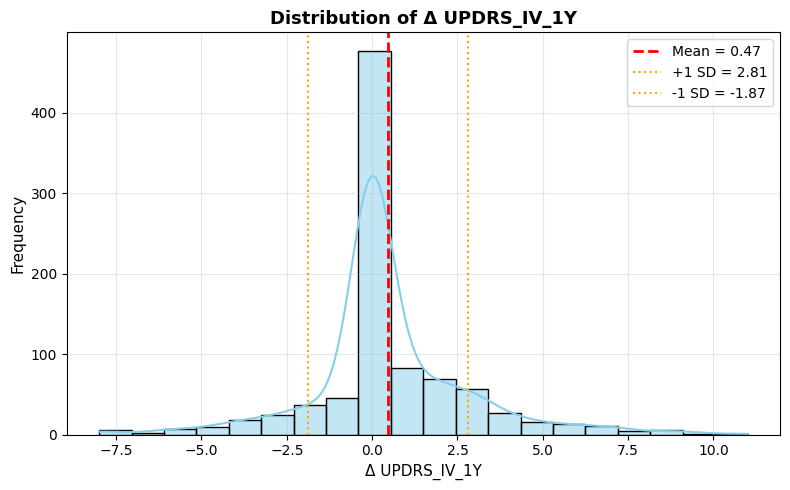

Statistical descriptors:
count    911.000000
mean       0.469813
std        2.340499
min       -8.000000
25%        0.000000
50%        0.000000
75%        1.000000
max       11.000000
Name: Δ UPDRS_IV_1Y, dtype: float64


In [317]:
plot_hist_with_stats(motor_data,'Δ UPDRS_IV_1Y', bins=20)

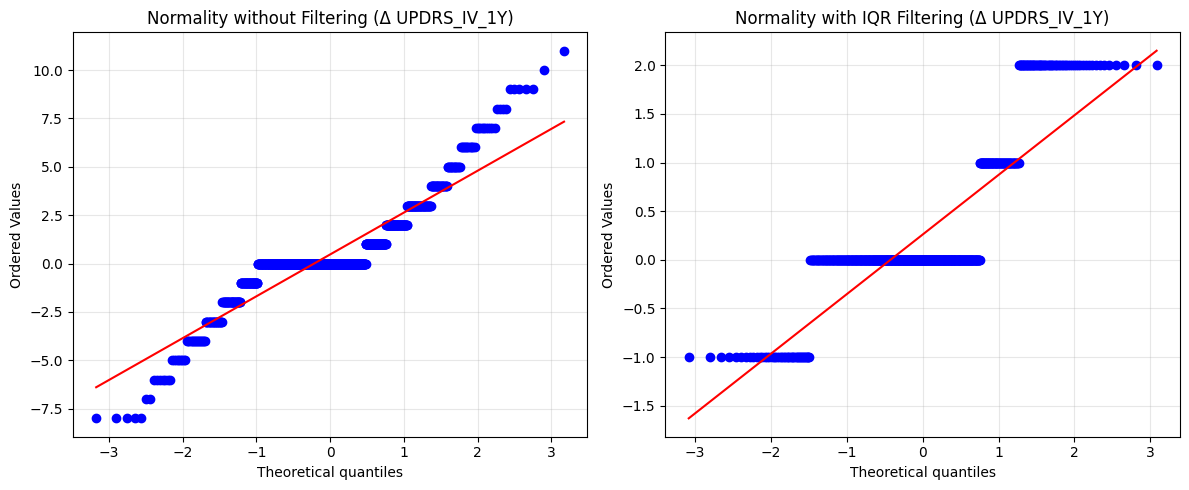

Original — χ²=104.293, p-value=0.0000
❌ Se rechaza normalidad

Filtrado — χ²=114.178, p-value=0.0000
❌ Se rechaza normalidad

0.0 1.0 -1.5 2.5


In [318]:
qq_plot_with_iqr_filtering(motor_data,'Δ UPDRS_IV_1Y')

#### Δ UPDRS TOTA

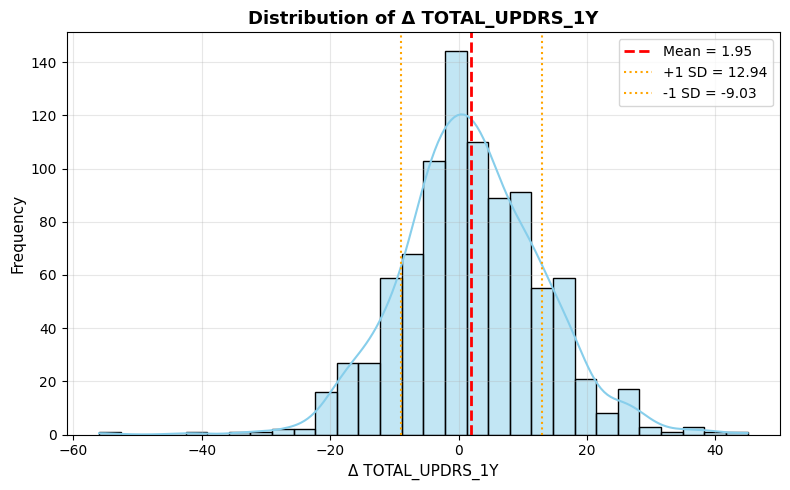

Statistical descriptors:
count    911.000000
mean       1.953897
std       10.985608
min      -56.000000
25%       -5.000000
50%        2.000000
75%        9.000000
max       45.000000
Name: Δ TOTAL_UPDRS_1Y, dtype: float64


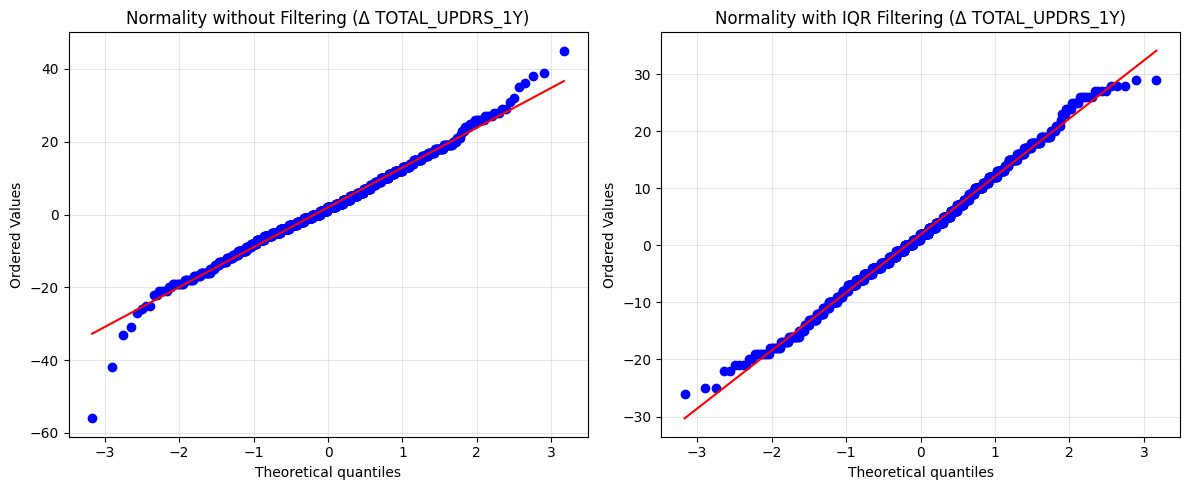

Original — χ²=26.843, p-value=0.0000
❌ Se rechaza normalidad

Filtrado — χ²=2.232, p-value=0.3276
✅ No se rechaza normalidad

-5.0 9.0 -26.0 30.0


In [319]:
plot_hist_with_stats(motor_data,  'Δ TOTAL_UPDRS_1Y')
qq_plot_with_iqr_filtering(motor_data,'Δ TOTAL_UPDRS_1Y')

### UPDRS LPA

In [320]:
cols = ["Δ UPDRS_I_1Y", "Δ UPDRS_II_1Y", "Δ UPDRS_III_1Y"]
data_clustering = motor_data[cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_clustering)


In [321]:
from sklearn.mixture import GaussianMixture
n_components = range(1, 7)   # por ejemplo, de 1 a 6 perfiles
models = []
bics = []
aics = []

for k in n_components:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='diag',
        random_state=123,
        n_init=10
    )
    gmm.fit(X_scaled)
    models.append(gmm)
    bics.append(gmm.bic(X_scaled))
    aics.append(gmm.aic(X_scaled))
    print(f"k={k}: BIC={gmm.bic(X_scaled):.1f}, AIC={gmm.aic(X_scaled):.1f}")

# Elegir el k con menor BIC
best_index = int(np.argmin(bics))
best_k = n_components[best_index]
best_gmm = models[best_index]

print(f"\nMejor número de perfiles según BIC: k = {best_k}")


k=1: BIC=7796.8, AIC=7767.9
k=2: BIC=7759.3, AIC=7696.7
k=3: BIC=7639.9, AIC=7543.6
k=4: BIC=7667.2, AIC=7537.3
k=5: BIC=7650.5, AIC=7486.8
k=6: BIC=7714.6, AIC=7517.2

Mejor número de perfiles según BIC: k = 3


In [322]:
# Probabilidades de pertenencia a cada perfil
probs = best_gmm.predict_proba(X_scaled)

# Perfil asignado (el de mayor probabilidad)
clusters = best_gmm.predict(X_scaled)

# Guardar en el df original (respetando los índices de X)
data_clustering.loc[data_clustering.index, "Perfil_LPA"] = clusters

# Guardar también las probabilidades de cada perfil (opcional pero recomendable)
for j in range(best_k):
    data_clustering.loc[data_clustering.index, f"Prob_Perfil_{j}"] = probs[:, j]


In [323]:
data_clustering

,Δ UPDRS_I_1Y,Δ UPDRS_II_1Y,Δ UPDRS_III_1Y,Perfil_LPA,Prob_Perfil_0,Prob_Perfil_1,Prob_Perfil_2
728,1,-1.0,-9,1.0,0.033846,0.689994,0.276160
729,2,-1.0,-14,1.0,0.051024,0.484044,0.464932
730,0,4.0,16,0.0,0.577085,0.314720,0.108195
561,-1,0.0,3,1.0,0.034403,0.836803,0.128794
562,3,1.0,5,1.0,0.174033,0.733102,0.092865
...,...,...,...,...,...,...,...
155,3,2.0,-1,1.0,0.191417,0.693981,0.114602
156,-3,-3.0,-4,2.0,0.018608,0.148884,0.832508
157,-1,0.0,-8,1.0,0.025659,0.722653,0.251687
158,-1,0.0,-9,1.0,0.025720,0.698184,0.276096


In [324]:
# Medias de los perfiles en la escala estandarizada
means_scaled = best_gmm.means_

# Volver a la escala original de las variables
means_original = scaler.inverse_transform(means_scaled)

profile_means = pd.DataFrame(means_original, columns=cols)
profile_means.index = [f"Perfil_{j}" for j in range(best_k)]

print(profile_means)

data_clustering['Perfil_LPA']= data_clustering['Perfil_LPA'].map({0:'General Progress.',1:'Stability',2:'General Improv.'})
motor_data['Perfil_LPA']= data_clustering['Perfil_LPA']
print(motor_data.groupby('Perfil_LPA')[cols].mean())


          Δ UPDRS_I_1Y  Δ UPDRS_II_1Y  Δ UPDRS_III_1Y
Perfil_0      2.578146       4.208972        3.840021
Perfil_1      0.371812       0.636665        0.743952
Perfil_2     -0.842700      -1.523313       -2.879068
                   Δ UPDRS_I_1Y  Δ UPDRS_II_1Y  Δ UPDRS_III_1Y
Perfil_LPA                                                    
General Improv.       -1.719048      -2.742857       -4.385714
General Progress.      3.304094       5.315789        4.040936
Stability              0.420755       0.632075        0.918868


- Perfil 0 – “Mejoría global”
- Perfil 1 - "Progresión global"
- Perfil 2 - “Estabilidad / No progresión”


(array([0, 1, 2]),
 [Text(0, 0, 'Stability'),
  Text(1, 0, 'General Improv.'),
  Text(2, 0, 'General Progress.')])

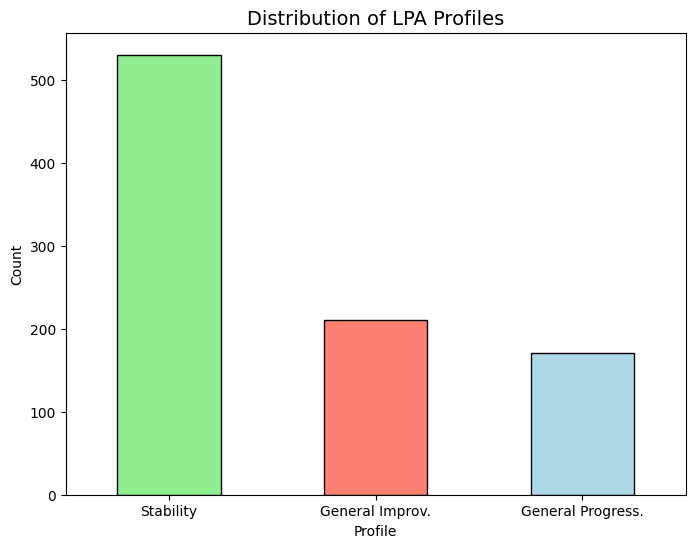

In [325]:
motor_data['Perfil_LPA'].value_counts().plot(kind='bar', color=['lightgreen','salmon','lightblue'], edgecolor='black', figsize=(8,6))
plt.title('Distribution of LPA Profiles', fontsize=14)
plt.xlabel('Profile')
plt.ylabel('Count')
plt.xticks(rotation=0)

### H&Y Distribution

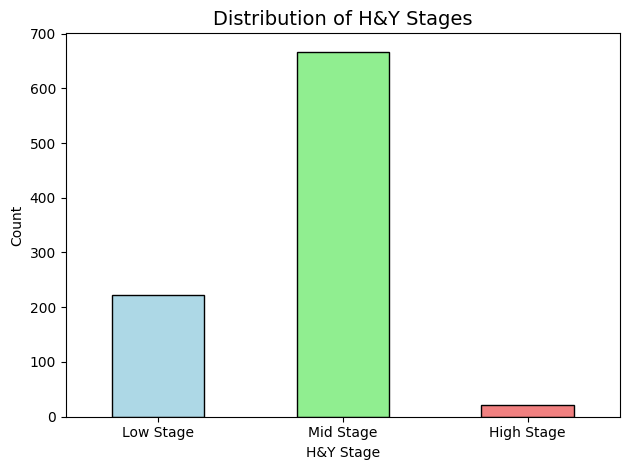

In [326]:
motor_data['H&Y_Stage'] = motor_data['3.21 HOEHN AND YAHR STAGE'].replace({
    0: 'Low Stage',
    1: 'Low Stage',
    2: 'Mid Stage',
    3: 'High Stage',
    4: 'High Stage'
})

# Definir el orden deseado
stage_order = ['Low Stage', 'Mid Stage', 'High Stage']

# Contar y reordenar
counts = motor_data['H&Y_Stage'].value_counts().reindex(stage_order)

# Colores solicitados
colors = ['lightblue', 'lightgreen', 'lightcoral']

# Graficar
counts.plot(kind='bar', color=colors, edgecolor='black')

# Personalización
plt.title('Distribution of H&Y Stages', fontsize=14)
plt.xlabel('H&Y Stage')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### S&E ADL


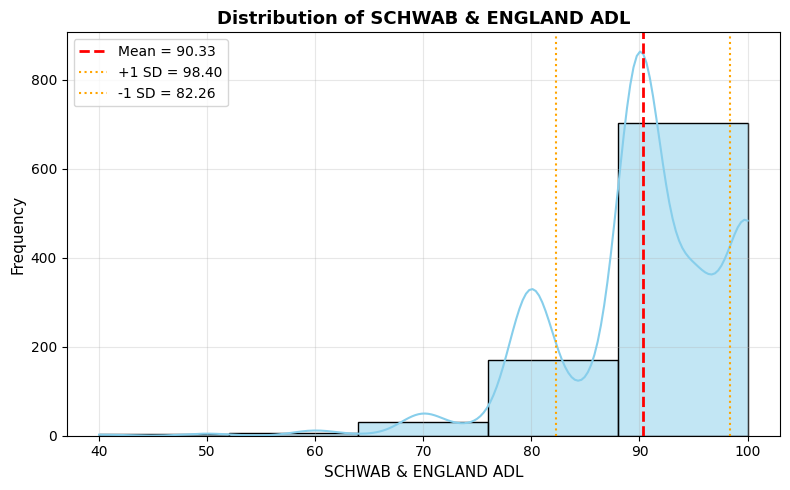

Statistical descriptors:
count    911.000000
mean      90.329308
std        8.069152
min       40.000000
25%       90.000000
50%       90.000000
75%       95.000000
max      100.000000
Name: SCHWAB & ENGLAND ADL, dtype: float64


In [327]:
plot_hist_with_stats(motor_data,  'SCHWAB & ENGLAND ADL', bins=5)



## COGNITIVE DATA

In [328]:
cognitive_data = pd.read_csv('/Users/fserracrespi/Desktop/PD_Project_UofL/PD_DATA/PD_1y_progress_DATA/Data_Cognitive_1Year_12SEP2025.csv')
cognitive_data.drop(columns=['Unnamed: 0'],inplace=True)
cognitive_data.sort_values(by=['PATNO','Visit ID'], inplace=True)
# UPDRS Class
cognitive_data = clasificar_updrs_thresholds(cognitive_data)

cognitive_data['UPDRS_I_ProgressionType'] = cognitive_data['Δ UPDRS_I_1Y'].apply(lambda delta: categorize_progression(delta, -3,3 ))
cognitive_data['UPDRS_II_ProgressionType'] = cognitive_data['Δ UPDRS_II_1Y'].apply(lambda delta: categorize_progression(delta, -3,5 ))
cognitive_data['UPDRS_III_ProgressionType'] = cognitive_data['Δ UPDRS_III_1Y'].apply(lambda delta: categorize_progression(delta, -3,5 ))

# binary class creation
cognitive_data['YNProgression'] = cognitive_data['Δ TOTAL_UPDRS_1Y'].apply(categorize_progression2)
cognitive_data['UPDRS_I_YNProgression'] = cognitive_data['Δ UPDRS_I_1Y'].apply(categorize_progression2)
cognitive_data['UPDRS_II_YNProgression'] = cognitive_data['Δ UPDRS_II_1Y'].apply(categorize_progression2)
cognitive_data['UPDRS_III_YNProgression'] = cognitive_data['Δ UPDRS_III_1Y'].apply(categorize_progression2)


cognitive_data=cognitive_data.merge(
    motor_data[['PATNO','Visit ID','Perfil_LPA']],
    on=['PATNO','Visit ID'],
    how='inner'
)


# imputation 
cognitive_data['Motor Exam assessment'].replace({'Unable to test':'Normal','Unable to test':'Normal'}, inplace=True)
cognitive_data['Coordination assessment'].replace({'Unable to test':'Normal','Unable to test':'Normal'}, inplace=True)
cognitive_data['Sensory Exam assessment'].replace({'Not tested':'Normal','Unable to test':'Normal'}, inplace=True)
cognitive_data['Reflexes assessment'].replace({'Not tested':'Normal','Unable to test':'Normal'}, inplace=True)
cognitive_data['CN II-XII assessment'].replace({'Not tested':'Normal','Unable to test':'Normal'}, inplace=True)

cognitive_data.head(3)

/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_27348/1611086879.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cognitive_data['Motor Exam assessment'].replace({'Unable to test':'Normal','Unable to test':'Normal'}, inplace=True)
/var/folders/vr/_v9wq92941bflv75jsh8kq800000gn/T/ipykernel_27348/1611086879.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never wo

,PATNO,Visit ID,Letter-Number Sequencing Scaled Score,STAI PART I Score,STAI PART II Score,STAI Total Score,MDS-UPDRS Part I (Patient Questionnaire) Total Score,MDS-UPDRS Part II Total Score,MDS-UPDRS Part III Total Score,MDS-UPDRS Part IV Total Score,...,UPDRS_III_Class,UPDRS_IV_Class,UPDRS_I_ProgressionType,UPDRS_II_ProgressionType,UPDRS_III_ProgressionType,YNProgression,UPDRS_I_YNProgression,UPDRS_II_YNProgression,UPDRS_III_YNProgression,Perfil_LPA
0,3001,V10_V12,18,53.0,50.0,103.0,6,5.0,35,0.0,...,Moderate,Mild,No significant change.,No significant change.,Substantial improv.,Improvement or no progress.,Progression.,Improvement or no progress.,Improvement or no progress.,Stability
1,3003,V10_V12,8,51.0,42.0,93.0,9,10.0,53,0.0,...,Moderate,Mild,No significant change.,No significant change.,Substantial improv.,Improvement or no progress.,Progression.,Improvement or no progress.,Improvement or no progress.,Stability
2,3010,V10_V12,12,44.0,40.0,84.0,11,16.0,18,7.0,...,Mild,Moderate,No significant change.,No significant change.,Substantial progress.,Progression.,Improvement or no progress.,Progression.,Progression.,General Progress.


In [329]:
cognitive_data.to_csv('/Users/fserracrespi/Desktop/PD_Project_UofL/PD_DATA/MODELS DEVELOPMENT/DATA FOR MODELS/Cognitive_Data.csv', index=False)

###  STAI

In [330]:
STAI_data = cognitive_data[['STAI PART I Score', 'STAI PART II Score','STAI Total Score','MDS-UPDRS Part I (Patient Questionnaire) Total Score','MDS-UPDRS Part II Total Score','MDS-UPDRS Part III Total Score','MDS-UPDRS Total Score','Δ TOTAL_UPDRS_1Y', 'Δ UPDRS_I_1Y', 'Δ UPDRS_II_1Y', 'Δ UPDRS_III_1Y','UPDRS_I_ProgressionType','UPDRS_II_ProgressionType','UPDRS_III_ProgressionType','YNProgression','UPDRS_I_YNProgression','UPDRS_II_YNProgression','UPDRS_III_YNProgression','Perfil_LPA']].copy()
STAI_data.head(3)

,STAI PART I Score,STAI PART II Score,STAI Total Score,MDS-UPDRS Part I (Patient Questionnaire) Total Score,MDS-UPDRS Part II Total Score,MDS-UPDRS Part III Total Score,MDS-UPDRS Total Score,Δ TOTAL_UPDRS_1Y,Δ UPDRS_I_1Y,Δ UPDRS_II_1Y,Δ UPDRS_III_1Y,UPDRS_I_ProgressionType,UPDRS_II_ProgressionType,UPDRS_III_ProgressionType,YNProgression,UPDRS_I_YNProgression,UPDRS_II_YNProgression,UPDRS_III_YNProgression,Perfil_LPA
0,53.0,50.0,103.0,6,5.0,35,46.0,-9.0,1,-1.0,-9,No significant change.,No significant change.,Substantial improv.,Improvement or no progress.,Progression.,Improvement or no progress.,Improvement or no progress.,Stability
1,51.0,42.0,93.0,9,10.0,53,72.0,-13.0,2,-1.0,-14,No significant change.,No significant change.,Substantial improv.,Improvement or no progress.,Progression.,Improvement or no progress.,Improvement or no progress.,Stability
2,44.0,40.0,84.0,11,16.0,18,52.0,18.0,0,4.0,16,No significant change.,No significant change.,Substantial progress.,Progression.,Improvement or no progress.,Progression.,Progression.,General Progress.


#### STAI Correlation Matrix

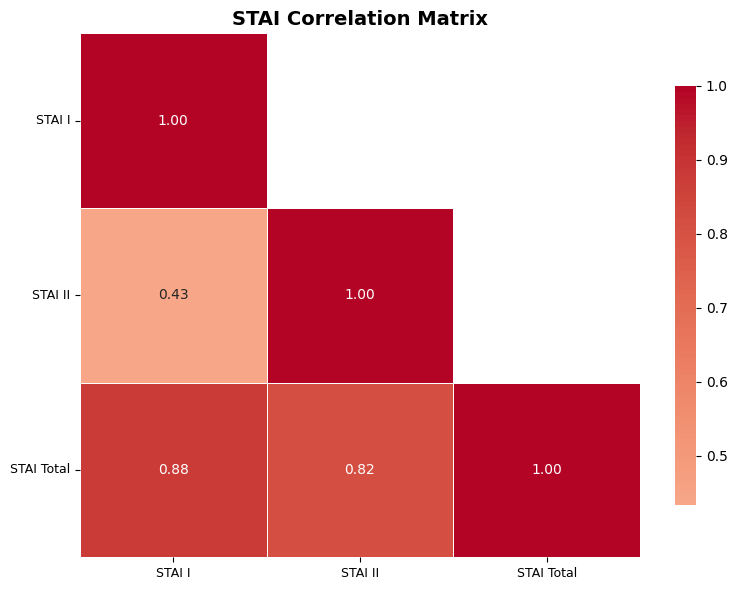

In [331]:

STAI_corr = STAI_data[STAI_data.columns[:3]].corr()
# Renombrar columnas e índices (más corto y legible)
STAI_corr.columns = [
    'STAI I',
    'STAI II',
    'STAI Total',
]

STAI_corr.index = STAI_corr.columns  # mantener consistencia filas/columnas
# Create a mask to display only the lower triangle
mask = np.triu(np.ones_like(STAI_corr, dtype=bool), k=1)
# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    STAI_corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("STAI Correlation Matrix", fontsize=14, weight='bold')
plt.xticks(rotation=0, ha='center', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

#### STAI Total Distribution

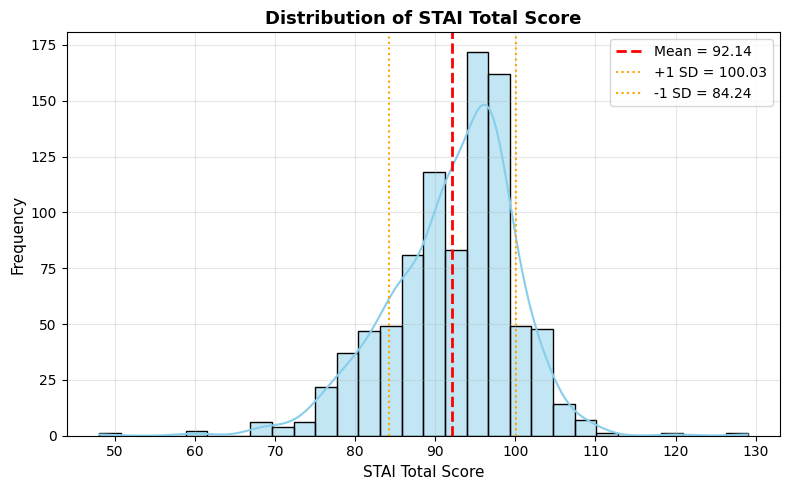

Statistical descriptors:
count    911.000000
mean      92.136114
std        7.893739
min       48.000000
25%       87.000000
50%       93.000000
75%       97.000000
max      129.000000
Name: STAI Total Score, dtype: float64


In [332]:
plot_hist_with_stats(STAI_data, 'STAI Total Score', bins=30)

#### STAI Parts Distribution

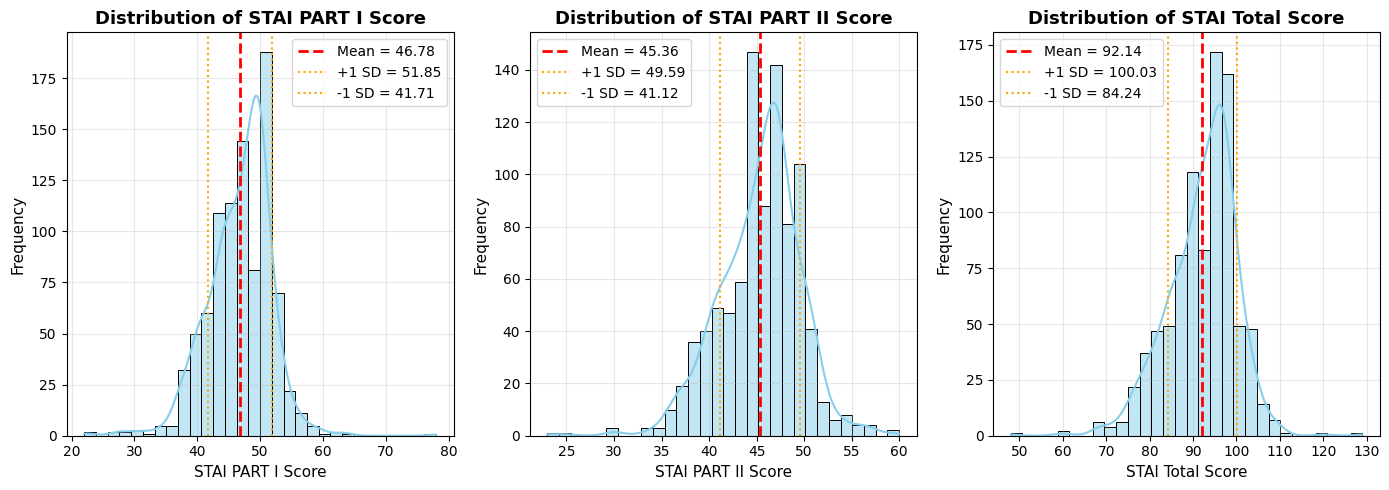

In [333]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

plot_hist_subplots(axes[0], cognitive_data, 'STAI PART I Score')
plot_hist_subplots(axes[1], cognitive_data, 'STAI PART II Score')
plot_hist_subplots(axes[2], cognitive_data, 'STAI Total Score')

plt.tight_layout()
plt.show()

### Geriatric GDS 

In [334]:
gds_data=cognitive_data[['GDS Short Score','Has Depression','MDS-UPDRS Part I (Patient Questionnaire) Total Score','MDS-UPDRS Part II Total Score','MDS-UPDRS Part III Total Score','MDS-UPDRS Total Score','Δ TOTAL_UPDRS_1Y', 'Δ UPDRS_I_1Y', 'Δ UPDRS_II_1Y', 'Δ UPDRS_III_1Y','UPDRS_I_ProgressionType','UPDRS_II_ProgressionType','UPDRS_III_ProgressionType','YNProgression','UPDRS_I_YNProgression','UPDRS_II_YNProgression','UPDRS_III_YNProgression','Perfil_LPA']].copy()
gds_data.head(3)

,GDS Short Score,Has Depression,MDS-UPDRS Part I (Patient Questionnaire) Total Score,MDS-UPDRS Part II Total Score,MDS-UPDRS Part III Total Score,MDS-UPDRS Total Score,Δ TOTAL_UPDRS_1Y,Δ UPDRS_I_1Y,Δ UPDRS_II_1Y,Δ UPDRS_III_1Y,UPDRS_I_ProgressionType,UPDRS_II_ProgressionType,UPDRS_III_ProgressionType,YNProgression,UPDRS_I_YNProgression,UPDRS_II_YNProgression,UPDRS_III_YNProgression,Perfil_LPA
0,1,False,6,5.0,35,46.0,-9.0,1,-1.0,-9,No significant change.,No significant change.,Substantial improv.,Improvement or no progress.,Progression.,Improvement or no progress.,Improvement or no progress.,Stability
1,2,False,9,10.0,53,72.0,-13.0,2,-1.0,-14,No significant change.,No significant change.,Substantial improv.,Improvement or no progress.,Progression.,Improvement or no progress.,Improvement or no progress.,Stability
2,4,False,11,16.0,18,52.0,18.0,0,4.0,16,No significant change.,No significant change.,Substantial progress.,Progression.,Improvement or no progress.,Progression.,Progression.,General Progress.


#### GDS Distribution

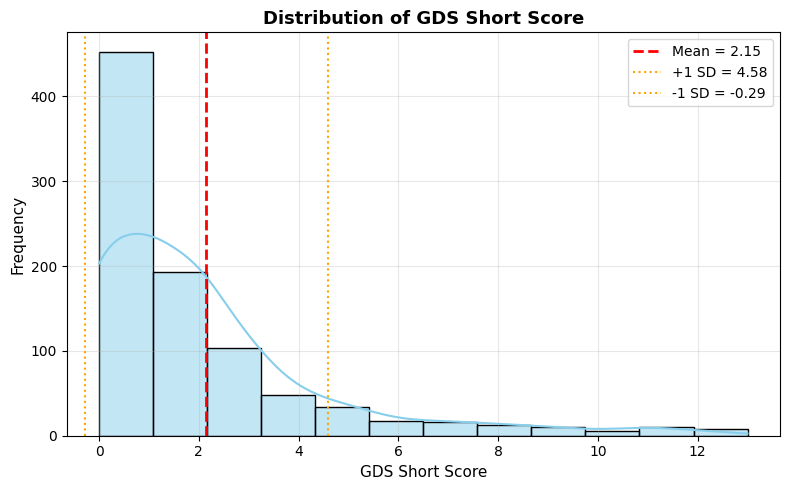

Statistical descriptors:
count    911.000000
mean       2.147091
std        2.433803
min        0.000000
25%        0.000000
50%        2.000000
75%        3.000000
max       13.000000
Name: GDS Short Score, dtype: float64


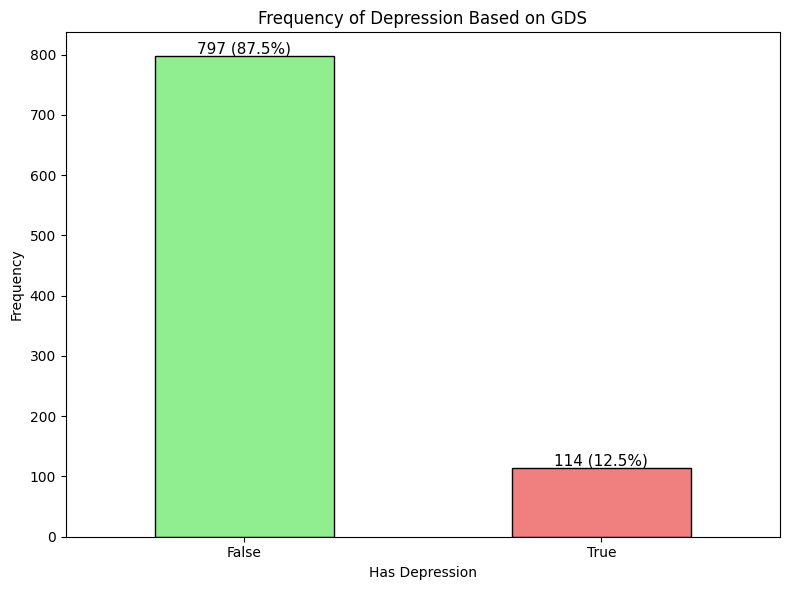

In [335]:
plot_hist_with_stats(gds_data, 'GDS Short Score', bins=12)
import matplotlib.pyplot as plt

# Crear el conteo
counts = gds_data['Has Depression'].value_counts()
total = counts.sum()

# Graficar
ax = counts.plot(
    kind='bar',
    figsize=(8,6),
    color=['lightgreen','lightcoral'],
    edgecolor='black'
)

# Etiquetas y título
plt.xlabel("Has Depression")
plt.ylabel("Frequency")
plt.title("Frequency of Depression Based on GDS")
plt.xticks(rotation=0)

# Añadir count y porcentaje encima de cada barra
for i, value in enumerate(counts):
    percentage = (value / total) * 100
    ax.text(
        i, 
        value, 
        f'{value} ({percentage:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.tight_layout()
plt.show()


#### GDS Correlation Matrix

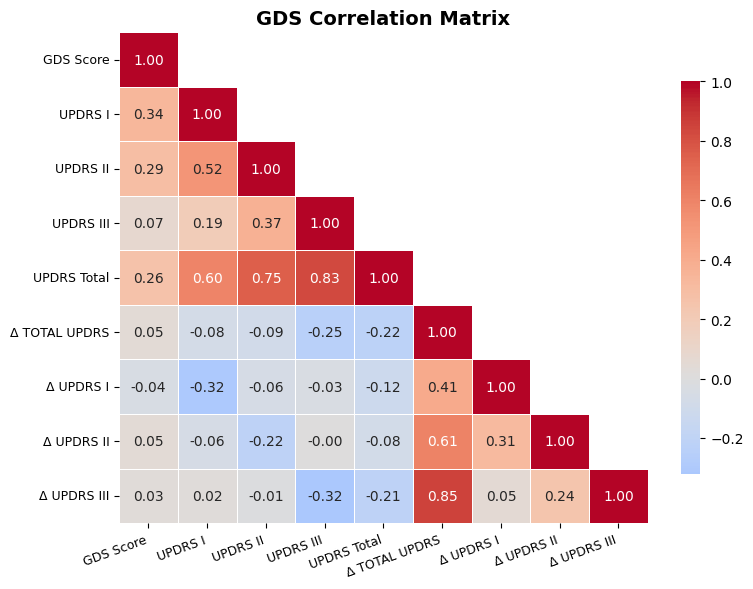

In [336]:

gds_data_cor= gds_data[['GDS Short Score','MDS-UPDRS Part I (Patient Questionnaire) Total Score','MDS-UPDRS Part II Total Score','MDS-UPDRS Part III Total Score','MDS-UPDRS Total Score','Δ TOTAL_UPDRS_1Y', 'Δ UPDRS_I_1Y', 'Δ UPDRS_II_1Y', 'Δ UPDRS_III_1Y']].corr()

# Renombrar columnas e índices (más corto y legible)
gds_data_cor.columns = [
    'GDS Score',
    'UPDRS I',
    'UPDRS II',
    'UPDRS III',
    'UPDRS Total',
    'Δ TOTAL UPDRS',
    'Δ UPDRS I',
    'Δ UPDRS II',
    'Δ UPDRS III'
]

gds_data_cor.index = gds_data_cor.columns  # mantener consistencia filas/columnas
# Create a mask to display only the lower triangle
mask = np.triu(np.ones_like(gds_data_cor, dtype=bool), k=1)
# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    gds_data_cor,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("GDS Correlation Matrix", fontsize=14, weight='bold')
plt.xticks(rotation=20, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

### NEURO

In [337]:
neuro_data = cognitive_data[['Motor Exam assessment',
                             'Coordination assessment',
                             'Sensory Exam assessment',
                             'Reflexes assessment',
                             'CN II-XII assessment',
                             'UPDRS_I_ProgressionType',
                             'UPDRS_II_ProgressionType',
                             'UPDRS_III_ProgressionType',
                             'YNProgression',
                             'Perfil_LPA',
                             'UPDRS_I_Class',
                             'UPDRS_II_Class',
                             'UPDRS_III_Class']].copy()

neuro_data.head(3)

,Motor Exam assessment,Coordination assessment,Sensory Exam assessment,Reflexes assessment,CN II-XII assessment,UPDRS_I_ProgressionType,UPDRS_II_ProgressionType,UPDRS_III_ProgressionType,YNProgression,Perfil_LPA,UPDRS_I_Class,UPDRS_II_Class,UPDRS_III_Class
0,Normal,Normal,Abnormal,Abnormal,Normal,No significant change.,No significant change.,Substantial improv.,Improvement or no progress.,Stability,Mild,Mild,Moderate
1,Normal,Normal,Abnormal,Abnormal,Normal,No significant change.,No significant change.,Substantial improv.,Improvement or no progress.,Stability,Mild,Mild,Moderate
2,Normal,Normal,Normal,Abnormal,Normal,No significant change.,No significant change.,Substantial progress.,Progression.,General Progress.,Moderate,Moderate,Mild


#### Neuro Distribution

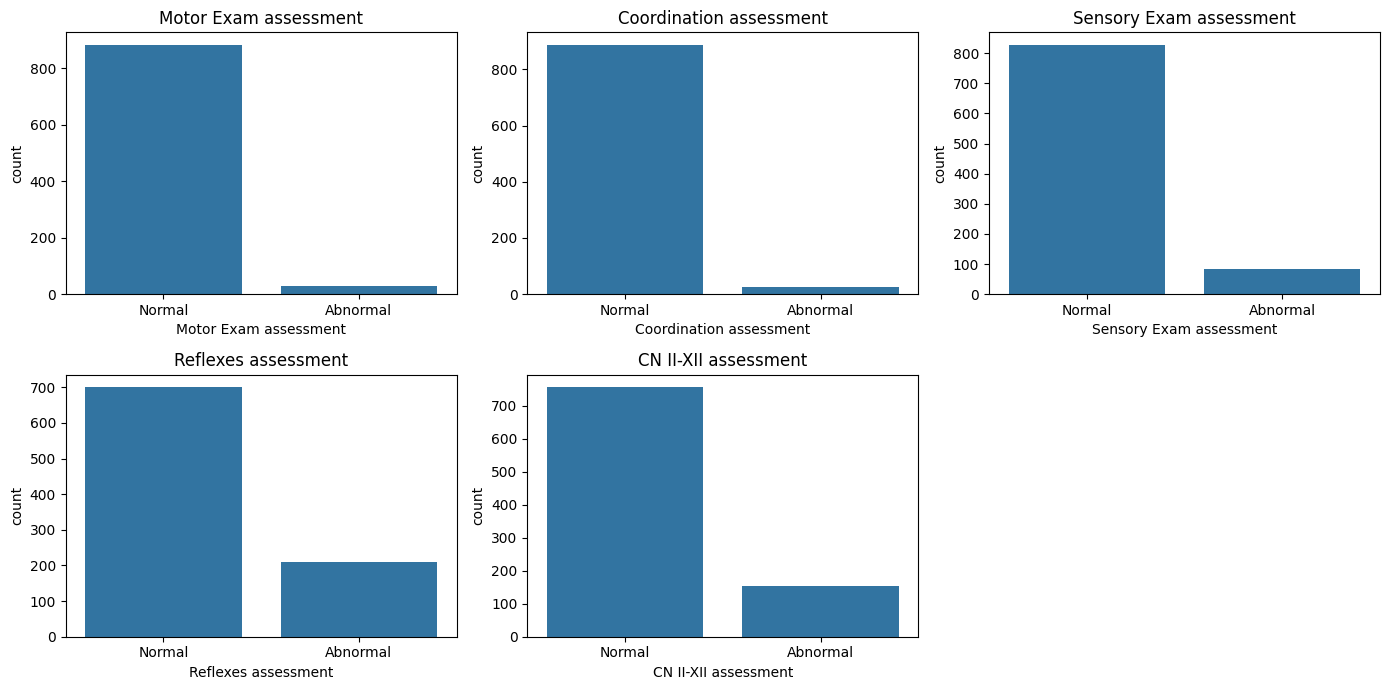

In [338]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

# Motor Exam
axes[0,0].set_title("Motor Exam assessment")
sns.countplot(x='Motor Exam assessment', data=neuro_data,
              ax=axes[0,0],
              order=neuro_data['Motor Exam assessment'].value_counts().index)

# Coordination
axes[0,1].set_title("Coordination assessment")
sns.countplot(x='Coordination assessment', data=neuro_data,
              ax=axes[0,1],
              order=neuro_data['Coordination assessment'].value_counts().index)

# Sensory Exam
axes[0,2].set_title("Sensory Exam assessment")
sns.countplot(x='Sensory Exam assessment', data=neuro_data,
              ax=axes[0,2],
              order=neuro_data['Sensory Exam assessment'].value_counts().index)

# Reflexes
axes[1,0].set_title("Reflexes assessment")
sns.countplot(x='Reflexes assessment', data=neuro_data,
              ax=axes[1,0],
              order=neuro_data['Reflexes assessment'].value_counts().index)

# CN II-XII
axes[1,1].set_title("CN II-XII assessment")
sns.countplot(x='CN II-XII assessment', data=neuro_data,
              ax=axes[1,1],
              order=neuro_data['CN II-XII assessment'].value_counts().index)

# Apagar el subplot vacío
axes[1,2].axis('off')

plt.tight_layout()
plt.show()


### HOPKINS

In [339]:
hopkins_data = cognitive_data[[
    'HVLT Total Recall Score',
    'HVLT Delayed Recall Score',
    'HVLT Retention Score',
    'HVLT Recognition Discrimination Index Score',
    'MDS-UPDRS Part I (Patient Questionnaire) Total Score',
    'MDS-UPDRS Part II Total Score',
    'MDS-UPDRS Part III Total Score',
    'MDS-UPDRS Total Score',
    'Δ TOTAL_UPDRS_1Y',
    'Δ UPDRS_I_1Y', 
    'Δ UPDRS_II_1Y', 
    'Δ UPDRS_III_1Y'
]]

hopkins_data.head(3)

,HVLT Total Recall Score,HVLT Delayed Recall Score,HVLT Retention Score,HVLT Recognition Discrimination Index Score,MDS-UPDRS Part I (Patient Questionnaire) Total Score,MDS-UPDRS Part II Total Score,MDS-UPDRS Part III Total Score,MDS-UPDRS Total Score,Δ TOTAL_UPDRS_1Y,Δ UPDRS_I_1Y,Δ UPDRS_II_1Y,Δ UPDRS_III_1Y
0,60.0,56.0,48.0,44.0,6,5.0,35,46.0,-9.0,1,-1.0,-9
1,53.0,61.0,62.0,56.0,9,10.0,53,72.0,-13.0,2,-1.0,-14
2,35.0,44.0,56.0,30.0,11,16.0,18,52.0,18.0,0,4.0,16


#### HOPKINS Distribution

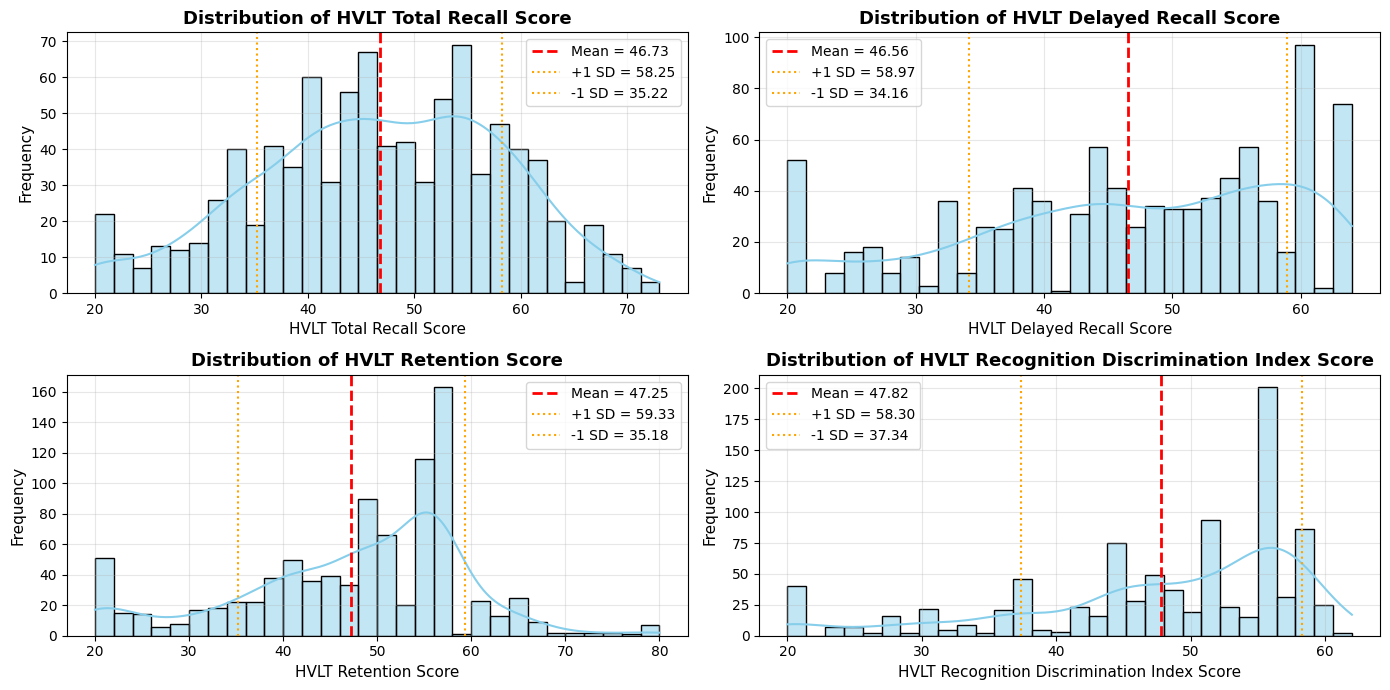

In [340]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))

plot_hist_subplots(axes[0,0], hopkins_data, "HVLT Total Recall Score")
plot_hist_subplots(axes[0,1], hopkins_data, "HVLT Delayed Recall Score")
plot_hist_subplots(axes[1,0], hopkins_data, "HVLT Retention Score")
plot_hist_subplots(axes[1,1], hopkins_data, "HVLT Recognition Discrimination Index Score")


plt.tight_layout()
plt.show()

#### HOPKINS Correlation

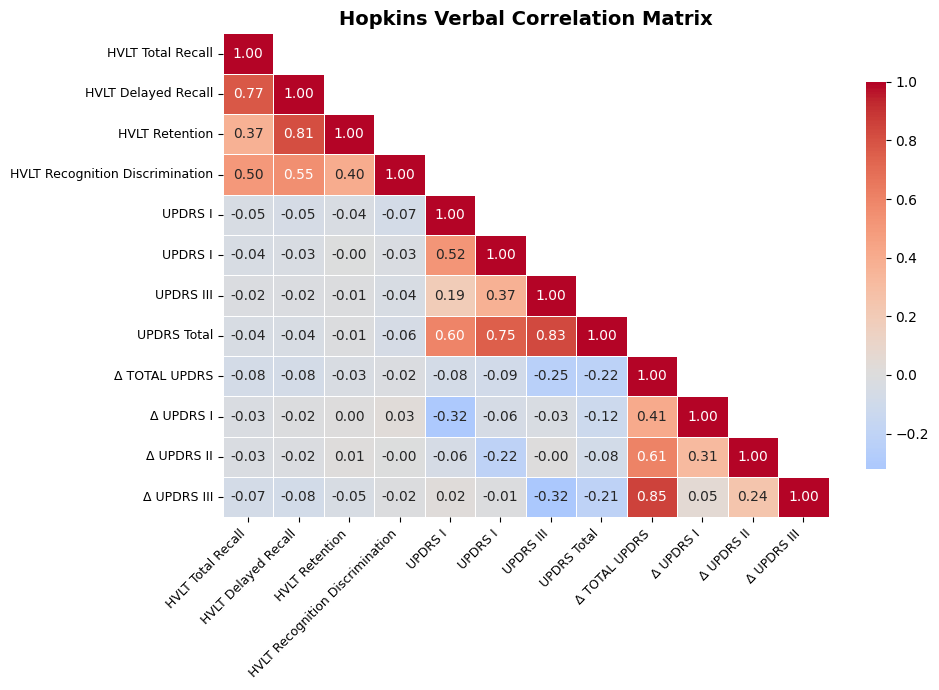

In [341]:
# Compute correlation matrix
corr_hopkins = hopkins_data.corr()

# Rename columns and index for readability
corr_hopkins.columns = [
    'HVLT Total Recall',
    'HVLT Delayed Recall',
    'HVLT Retention',
    'HVLT Recognition Discrimination',
    'UPDRS I',
    'UPDRS I',
    'UPDRS III',
    'UPDRS Total',
    'Δ TOTAL UPDRS',
    'Δ UPDRS I',
    'Δ UPDRS II',
    'Δ UPDRS III'
]
corr_hopkins.index = corr_hopkins.columns

# Mask the upper triangle (optional, for cleaner visualization)
mask = np.triu(np.ones_like(corr_hopkins, dtype=bool),k=1)

# Create the heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_hopkins,           
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Hopkins Verbal Correlation Matrix", fontsize=14, weight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()


### LETTER


In [342]:
letter_data = cognitive_data[[
    'Letter-Number Sequencing Scaled Score', 'MDS-UPDRS Part I (Patient Questionnaire) Total Score',
    'MDS-UPDRS Part II Total Score',
    'MDS-UPDRS Part III Total Score',
    'MDS-UPDRS Total Score',
    'Δ TOTAL_UPDRS_1Y',
    'Δ UPDRS_I_1Y', 
    'Δ UPDRS_II_1Y', 
    'Δ UPDRS_III_1Y'
]]


#### Letter Correlation

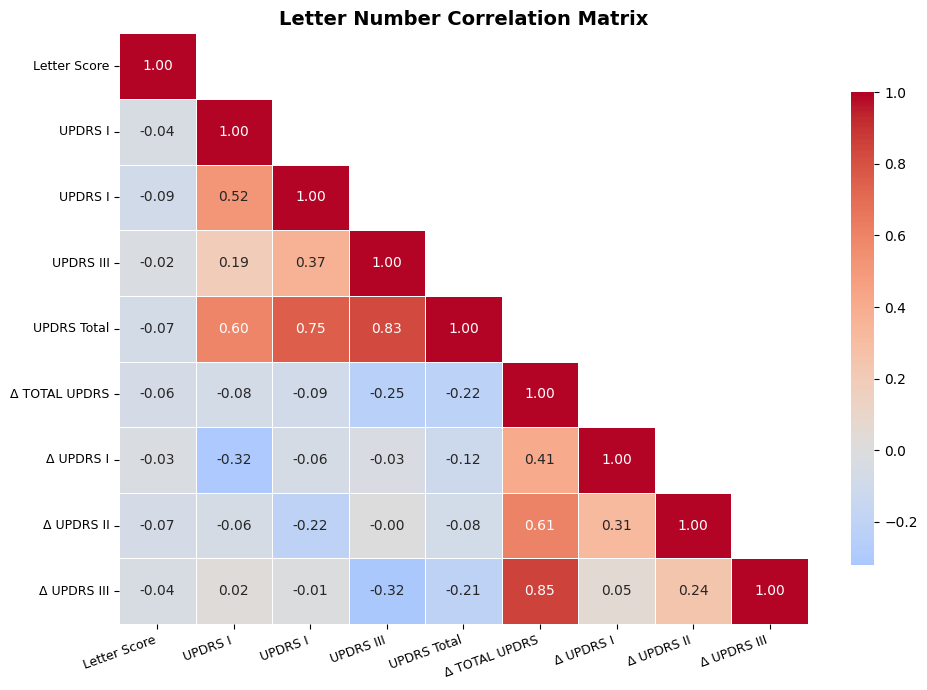

In [343]:
corr_letter= letter_data.corr()


# Rename columns and index for readability
corr_letter.columns = [
    'Letter Score',
     'UPDRS I',
    'UPDRS I',
    'UPDRS III',
    'UPDRS Total',
    'Δ TOTAL UPDRS',
    'Δ UPDRS I',
    'Δ UPDRS II',
    'Δ UPDRS III'
]
corr_letter.index = corr_letter.columns

# Mask the upper triangle (optional, for cleaner visualization)
mask = np.triu(np.ones_like(corr_letter, dtype=bool),k=1)

# Create the heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_letter,           
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Letter Number Correlation Matrix", fontsize=14, weight='bold')
plt.xticks(rotation=20, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

#### Letter Distribution

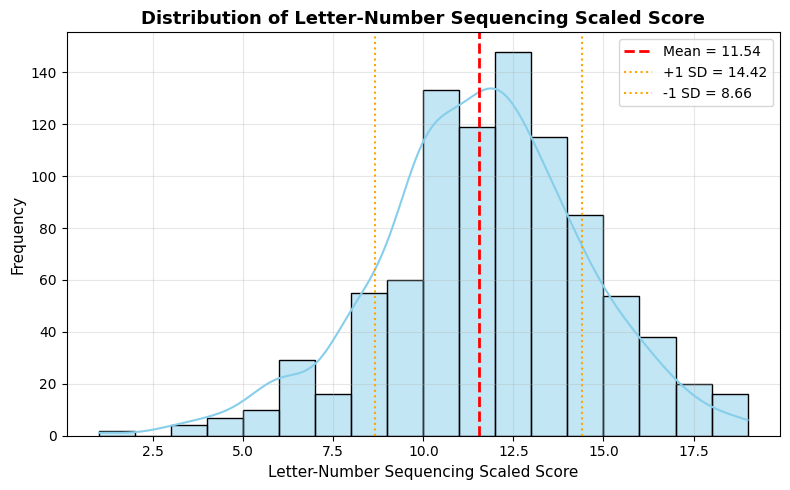

Statistical descriptors:
count    911.000000
mean      11.537870
std        2.878576
min        1.000000
25%       10.000000
50%       12.000000
75%       13.000000
max       19.000000
Name: Letter-Number Sequencing Scaled Score, dtype: float64


In [344]:
plot_hist_with_stats(letter_data, 'Letter-Number Sequencing Scaled Score', bins=18)

### SEMANTIC

In [345]:
semantic_data = cognitive_data[[
    'Semantic Fluency Scaled Score',
    'MDS-UPDRS Part I (Patient Questionnaire) Total Score',
    'MDS-UPDRS Part II Total Score',
    'MDS-UPDRS Part III Total Score',
    'MDS-UPDRS Total Score',
    'Δ TOTAL_UPDRS_1Y',
    'Δ UPDRS_I_1Y', 
    'Δ UPDRS_II_1Y', 
    'Δ UPDRS_III_1Y'
]]

#### Semantic Correlation

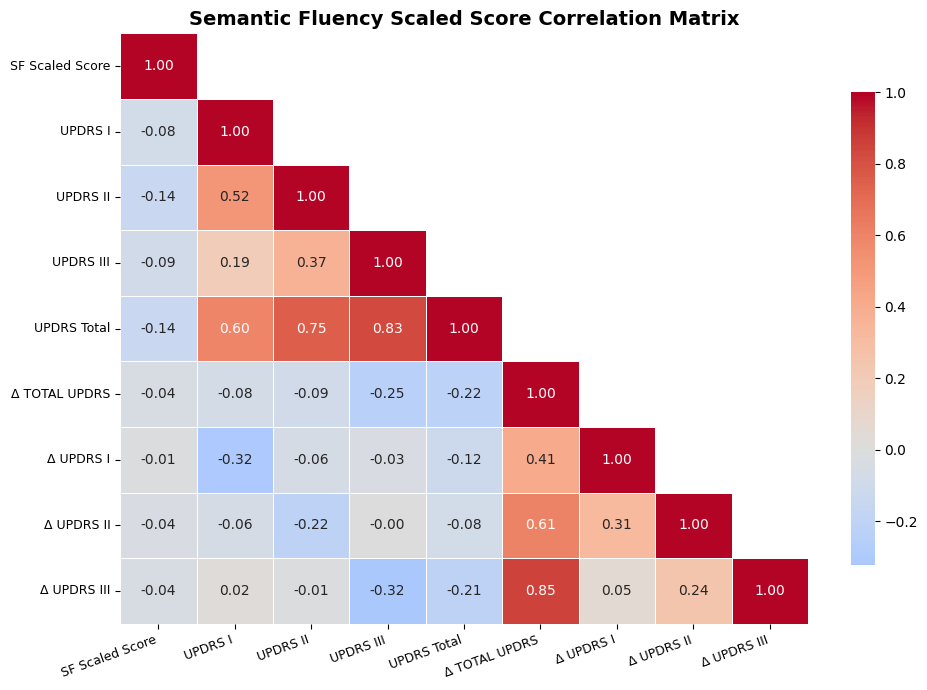

In [346]:
semantic_corr = semantic_data.corr()

# Rename columns and index for readability
semantic_corr.columns = [
    'SF Scaled Score',
    'UPDRS I',
    'UPDRS II',
    'UPDRS III',
    'UPDRS Total',
    'Δ TOTAL UPDRS',
    'Δ UPDRS I',
    'Δ UPDRS II',
    'Δ UPDRS III'
]
semantic_corr.index = semantic_corr.columns

# Mask the upper triangle (optional, for cleaner visualization)
mask = np.triu(np.ones_like(semantic_corr, dtype=bool),k=1)

# Create the heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    semantic_corr,           
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Semantic Fluency Scaled Score Correlation Matrix", fontsize=14, weight='bold')
plt.xticks(rotation=20, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

#### Semantic Distribution

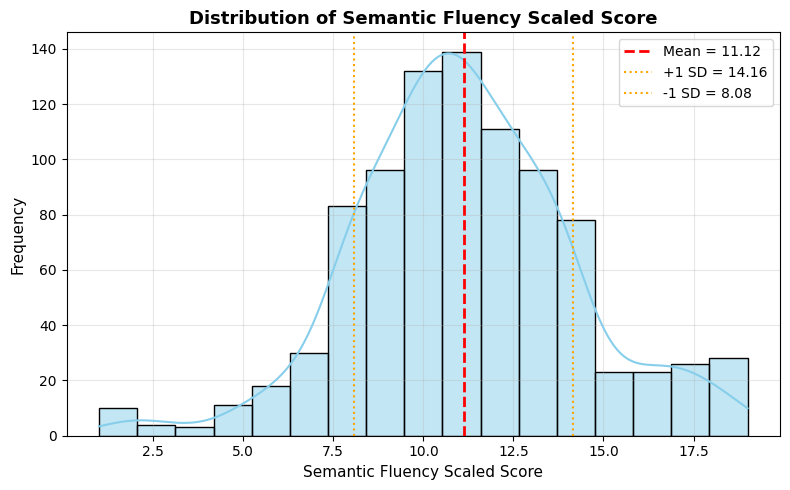

Statistical descriptors:
count    911.000000
mean      11.120746
std        3.043407
min        1.000000
25%        9.000000
50%       11.000000
75%       13.000000
max       19.000000
Name: Semantic Fluency Scaled Score, dtype: float64


In [347]:
plot_hist_with_stats(semantic_data, 'Semantic Fluency Scaled Score', bins=17)

### MOCA

In [348]:
moca_data = cognitive_data[['MoCA Total Score','VISUOSPATIAL_EXECUTIVE','NAMING','ATTENTION','LANGUAGE',
                            'ABSTRACTION','DELAYED_RECALL','ORIENTATION','MDS-UPDRS Part I (Patient Questionnaire) Total Score',
                            'MDS-UPDRS Part II Total Score',
                            'MDS-UPDRS Part III Total Score',
                            'MDS-UPDRS Total Score',
                            'Δ TOTAL_UPDRS_1Y',
                            'Δ UPDRS_I_1Y', 
                            'Δ UPDRS_II_1Y', 
                            'Δ UPDRS_III_1Y'
                        ]]
cognitive_data['MoCA State']= cognitive_data['MoCA Total Score'].apply(lambda x: 'Cognitive Impairment' if x < 26 else 'Normal Cognition')

#### MoCA Correlation

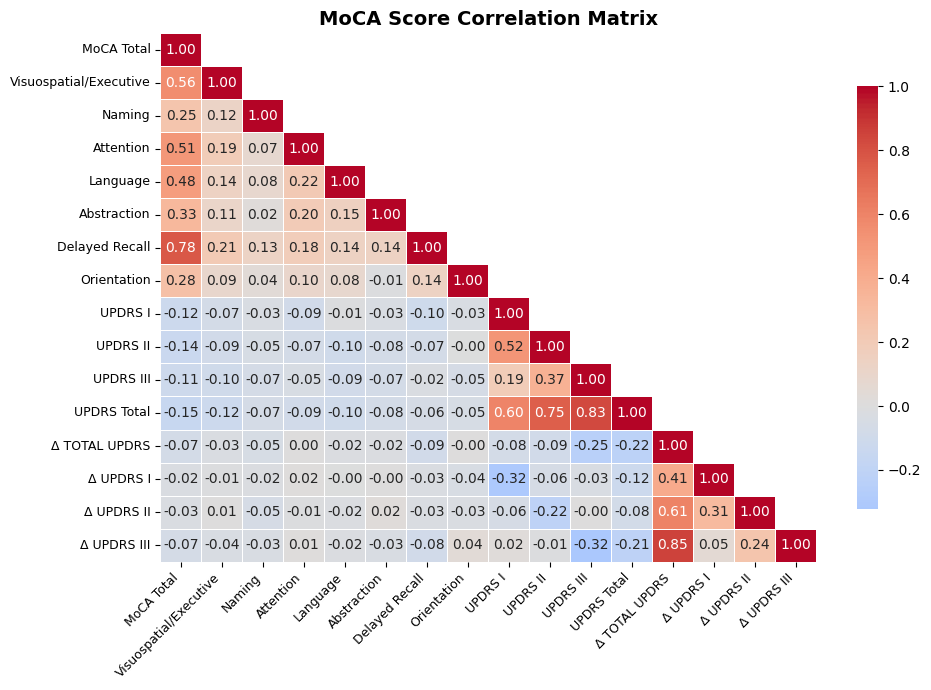

In [349]:

moca_corr = moca_data.corr()

# Rename columns and index for readability
moca_corr.columns = [
    'MoCA Total',
    'Visuospatial/Executive',
    'Naming',
    'Attention',
    'Language',
    'Abstraction',
    'Delayed Recall',
    'Orientation',
    'UPDRS I',
    'UPDRS II',
    'UPDRS III',
    'UPDRS Total',
    'Δ TOTAL UPDRS',
    'Δ UPDRS I',
    'Δ UPDRS II',
    'Δ UPDRS III'
]
moca_corr.index = moca_corr.columns

# Mask the upper triangle (optional, for cleaner visualization)
mask = np.triu(np.ones_like(moca_corr, dtype=bool),k=1)

# Create the heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    moca_corr,           
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("MoCA Score Correlation Matrix", fontsize=14, weight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()


#### MoCA Distribution

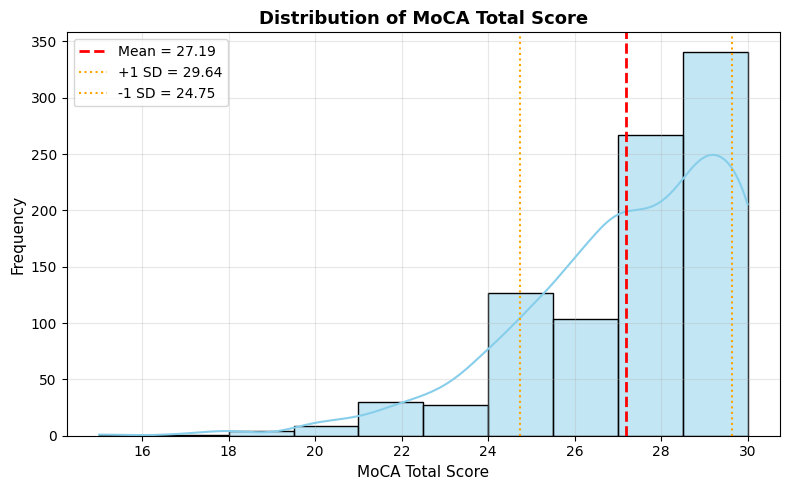

Statistical descriptors:
count    911.000000
mean      27.194292
std        2.447383
min       15.000000
25%       26.000000
50%       28.000000
75%       29.000000
max       30.000000
Name: MoCA Total Score, dtype: float64


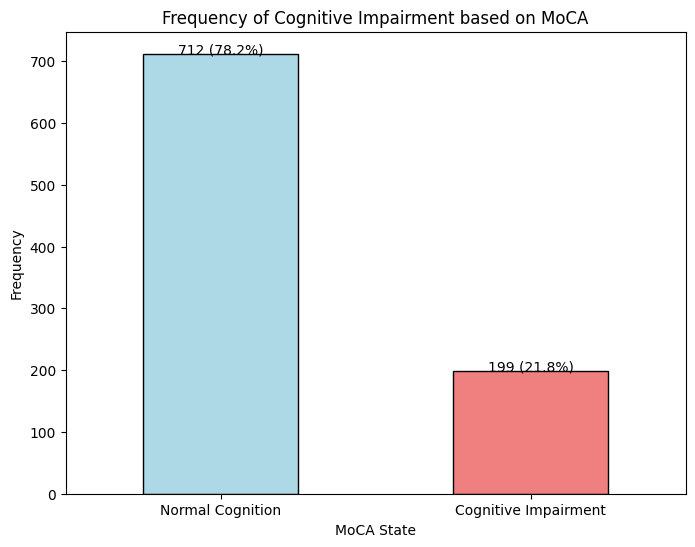

In [350]:
plot_hist_with_stats(moca_data, 'MoCA Total Score', bins=10)
# Conteo de clases
counts = cognitive_data['MoCA State'].value_counts()
percentages = counts / counts.sum() * 100

# Gráfico
ax = counts.plot(
    kind='bar',
    figsize=(8,6),
    color=['lightblue','lightcoral'],
    edgecolor='black'
)

plt.xlabel("MoCA State")
plt.ylabel("Frequency")
plt.title("Frequency of Cognitive Impairment based on MoCA")
plt.xticks(rotation=0)

# Añadir valores y porcentajes
for i, (count, pct) in enumerate(zip(counts, percentages)):
    ax.text(
        i, 
        count + 0.5, 
        f"{count} ({pct:.1f}%)",
        ha='center',
        fontsize=10
    )

plt.show()


### SYMBOLDIGIT



In [351]:
simbol_data = cognitive_data[['Symbol Digit Modalities Test Total Correct','MDS-UPDRS Part I (Patient Questionnaire) Total Score',
                            'MDS-UPDRS Part II Total Score',
                            'MDS-UPDRS Part III Total Score',
                            'MDS-UPDRS Total Score',
                            'Δ TOTAL_UPDRS_1Y',
                            'Δ UPDRS_I_1Y', 
                            'Δ UPDRS_II_1Y', 
                            'Δ UPDRS_III_1Y'
                        ]]


#### Symbol Correlation

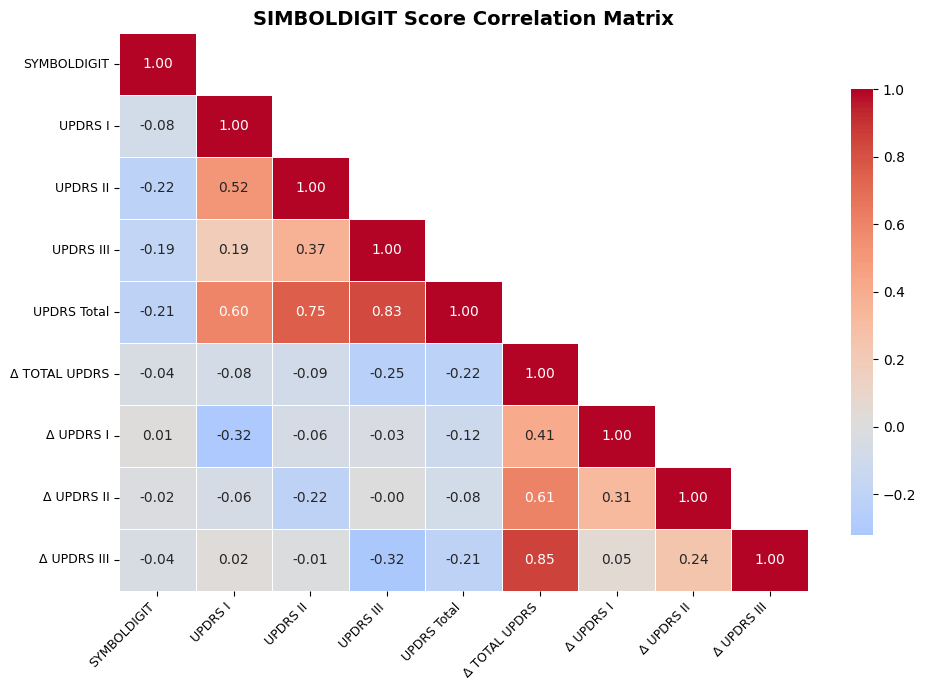

In [352]:

simbol_corr = simbol_data.corr()

# Rename columns and index for readability
simbol_corr.columns = [
    'SYMBOLDIGIT',
    'UPDRS I',
    'UPDRS II',
    'UPDRS III',
    'UPDRS Total',
    'Δ TOTAL UPDRS',
    'Δ UPDRS I',
    'Δ UPDRS II',
    'Δ UPDRS III'
]
simbol_corr.index = simbol_corr.columns

# Mask the upper triangle (optional, for cleaner visualization)
mask = np.triu(np.ones_like(simbol_corr, dtype=bool),k=1)

# Create the heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    simbol_corr,           
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("SIMBOLDIGIT Score Correlation Matrix", fontsize=14, weight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()


#### Symbol Distribution

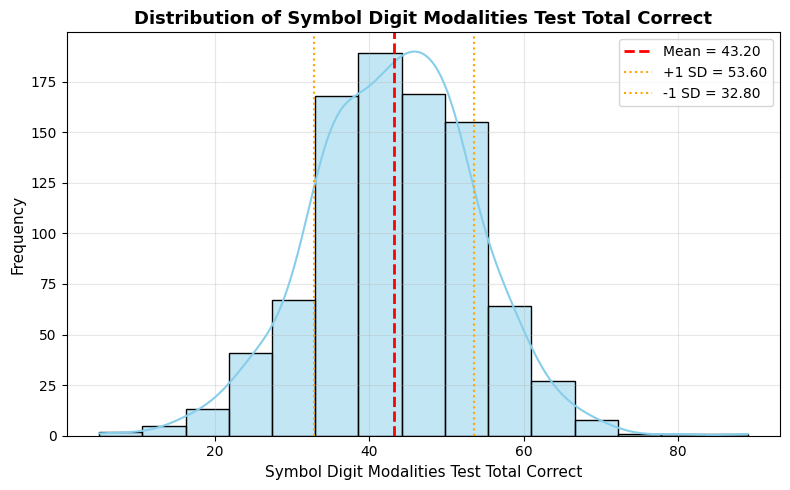

Statistical descriptors:
count    911.000000
mean      43.199780
std       10.398206
min        5.000000
25%       36.000000
50%       43.000000
75%       50.000000
max       89.000000
Name: Symbol Digit Modalities Test Total Correct, dtype: float64


In [353]:
plot_hist_with_stats(simbol_data, 'Symbol Digit Modalities Test Total Correct', bins=15)

### BENTONJLO

In [354]:
BENTONJLO_data = cognitive_data[['Benton Judgement of Line Orientation Scaled Score',
                            'MDS-UPDRS Part I (Patient Questionnaire) Total Score',
                            'MDS-UPDRS Part II Total Score',
                            'MDS-UPDRS Part III Total Score',
                            'MDS-UPDRS Total Score',
                            'Δ TOTAL_UPDRS_1Y',
                            'Δ UPDRS_I_1Y', 
                            'Δ UPDRS_II_1Y', 
                            'Δ UPDRS_III_1Y'
                        ]].copy()

BENTONJLO_data.head(3)

,Benton Judgement of Line Orientation Scaled Score,MDS-UPDRS Part I (Patient Questionnaire) Total Score,MDS-UPDRS Part II Total Score,MDS-UPDRS Part III Total Score,MDS-UPDRS Total Score,Δ TOTAL_UPDRS_1Y,Δ UPDRS_I_1Y,Δ UPDRS_II_1Y,Δ UPDRS_III_1Y
0,13.26,6,5.0,35,46.0,-9.0,1,-1.0,-9
1,15.46,9,10.0,53,72.0,-13.0,2,-1.0,-14
2,11.06,11,16.0,18,52.0,18.0,0,4.0,16


In [355]:
BENTONJLO_age= cognitive_data[['PATNO','Visit ID','Benton Judgement of Line Orientation Scaled Score','MoCA Total Score']].merge(subject_data[['PATNO','Visit ID','AGE_AT_VISIT']], on=['PATNO','Visit ID'], how='inner')

BENTONJLO_age[['Benton Judgement of Line Orientation Scaled Score','AGE_AT_VISIT','MoCA Total Score']].corr()


,Benton Judgement of Line Orientation Scaled Score,AGE_AT_VISIT,MoCA Total Score
Benton Judgement of Line Orientation Scaled Score,1.000000,-0.091565,0.289926
AGE_AT_VISIT,-0.091565,1.000000,-0.215535
MoCA Total Score,0.289926,-0.215535,1.000000


#### Benton JLO Correlation

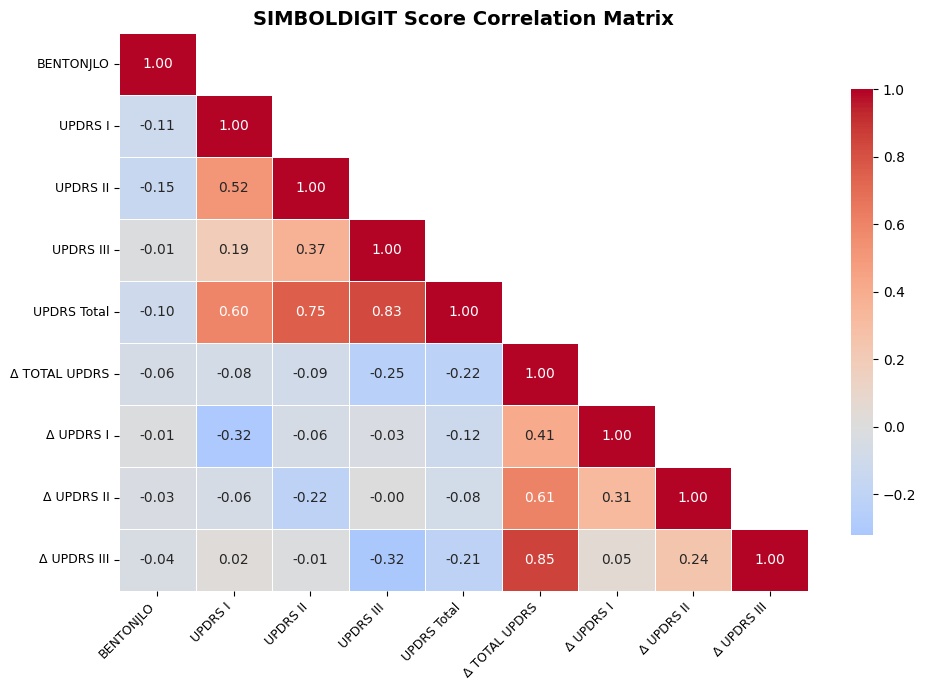

In [356]:

BENTONJLO_corr = BENTONJLO_data.corr()

# Rename columns and index for readability
BENTONJLO_corr.columns = [
    'BENTONJLO',
    'UPDRS I',
    'UPDRS II',
    'UPDRS III',
    'UPDRS Total',
    'Δ TOTAL UPDRS',
    'Δ UPDRS I',
    'Δ UPDRS II',
    'Δ UPDRS III'
]
BENTONJLO_corr.index = BENTONJLO_corr.columns

# Mask the upper triangle (optional, for cleaner visualization)
mask = np.triu(np.ones_like(BENTONJLO_corr, dtype=bool),k=1)

# Create the heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    BENTONJLO_corr,           
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("SIMBOLDIGIT Score Correlation Matrix", fontsize=14, weight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

#### Benton JLO Distribution

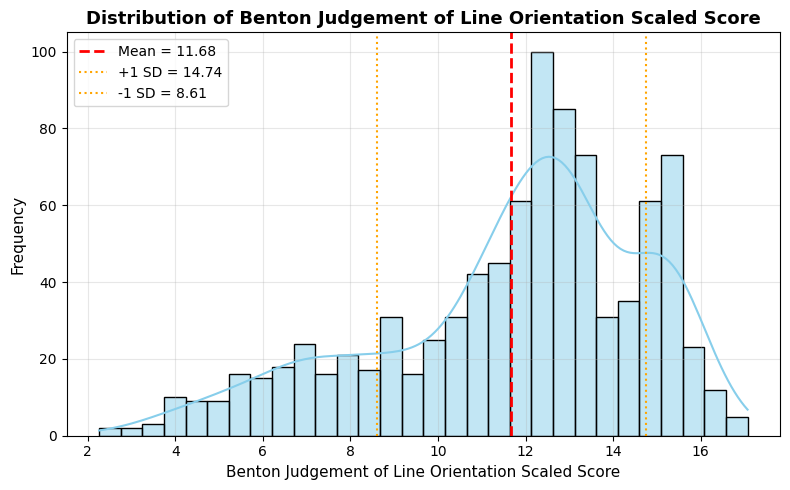

Statistical descriptors:
count    911.000000
mean      11.675763
std        3.063271
min        2.260000
25%       10.140000
50%       12.340000
75%       13.720000
max       17.070000
Name: Benton Judgement of Line Orientation Scaled Score, dtype: float64


In [357]:
plot_hist_with_stats(BENTONJLO_data, 'Benton Judgement of Line Orientation Scaled Score', bins=30)

## SLEEP DATA

In [358]:
sleep_data=pd.read_csv('/Users/fserracrespi/Desktop/PD_Project_UofL/PD_DATA/PD_1y_progress_DATA/Data_Sleep_1Year_12SEP2025.csv')
sleep_data.drop(columns=['Unnamed: 0'], inplace=True)

# UPDRS Class
    
sleep_data = clasificar_updrs_thresholds(sleep_data)


sleep_data=sleep_data.merge(cognitive_data[['PATNO','Visit ID','Perfil_LPA']], on=['PATNO','Visit ID'], how='left')
sleep_data['UPDRS_I_ProgressionType'] = sleep_data['Δ UPDRS_I_1Y'].apply(lambda delta: categorize_progression(delta, -3,3 ))
sleep_data['UPDRS_II_ProgressionType'] = sleep_data['Δ UPDRS_II_1Y'].apply(lambda delta: categorize_progression(delta, -3,5 ))
sleep_data['UPDRS_III_ProgressionType'] = sleep_data['Δ UPDRS_III_1Y'].apply(lambda delta: categorize_progression(delta, -3,5 ))

# binary class creation
sleep_data['YNProgression'] = sleep_data['Δ TOTAL_UPDRS_1Y'].apply(categorize_progression2)
sleep_data['UPDRS_I_YNProgression'] = sleep_data['Δ UPDRS_I_1Y'].apply(categorize_progression2)
sleep_data['UPDRS_II_YNProgression'] = sleep_data['Δ UPDRS_II_1Y'].apply(categorize_progression2)
sleep_data['UPDRS_III_YNProgression'] = sleep_data['Δ UPDRS_III_1Y'].apply(categorize_progression2)
sleep_data.head(3)


,PATNO,Visit ID,Sitting and reading,Watching TV,"Sitting, inactive in a public place",As a passenger in a car for an hour,Lying down to rest in the afternoon,Sitting and talking to someone,Sitting quietly after lunch,"In a car, while stopped in traffic",...,UPDRS_III_Class,UPDRS_IV_Class,Perfil_LPA,UPDRS_I_ProgressionType,UPDRS_II_ProgressionType,UPDRS_III_ProgressionType,YNProgression,UPDRS_I_YNProgression,UPDRS_II_YNProgression,UPDRS_III_YNProgression
0,100006,V04_V06,0,1,0.0,1,2,0.0,0,0,...,Mild,Mild,General Improv.,Substantial progress.,Substantial improv.,Substantial improv.,Improvement or no progress.,Progression.,Improvement or no progress.,Improvement or no progress.
1,100007,V04_V06,1,0,0.0,0,1,0.0,0,0,...,Mild,Mild,General Improv.,No significant change.,Substantial improv.,Substantial improv.,Improvement or no progress.,Improvement or no progress.,Improvement or no progress.,Improvement or no progress.
2,100012,V04_V06,1,1,0.0,0,1,0.0,1,0,...,Mild,Mild,Stability,No significant change.,No significant change.,No significant change.,Progression.,Progression.,Progression.,Progression.


### REM 

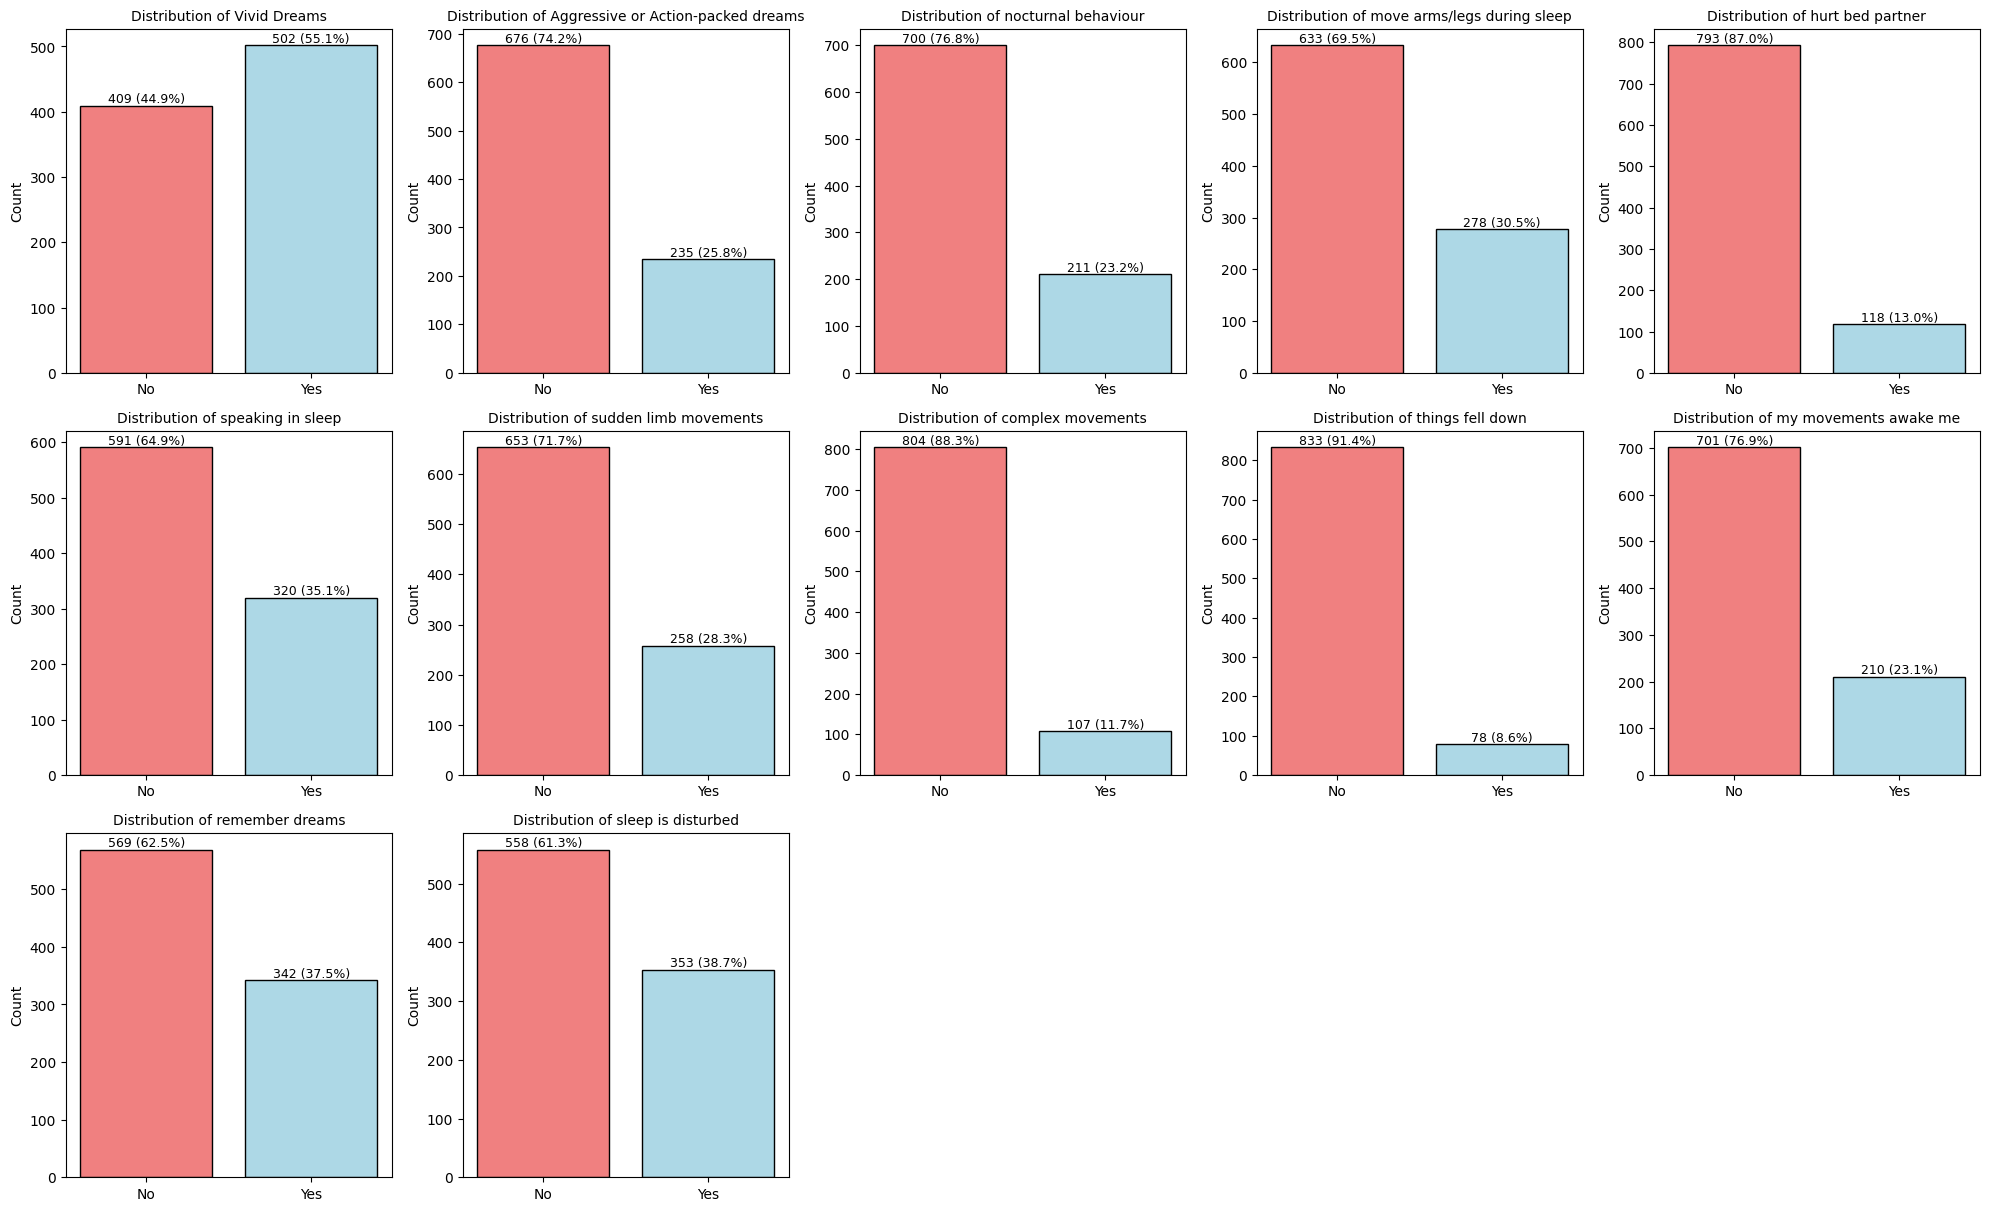

In [359]:
# Mapeo de variables a Yes/No (sin warning de SettingWithCopy)
rem_data = sleep_data[['Vivid Dreams','Aggressive or Action-packed dreams','nocturnal behaviour',
                        'move arms/legs during sleep','hurt bed partner','speaking in sleep',
                        'sudden limb movements','complex movements','things fell down',
                        'my movements awake me','remember dreams','sleep is disturbed',
                        'Restless Leg Syndrome (RLS)',
                        'UPDRS_I_ProgressionType','UPDRS_II_ProgressionType','UPDRS_III_ProgressionType','YNProgression',
                        'Perfil_LPA','UPDRS_I_Class','UPDRS_II_Class','UPDRS_III_Class']].copy()

rem_data = rem_data.replace({1: 'Yes', 0: 'No'})

# Colores personalizados
colors = {'Yes': 'lightblue', 'No': 'lightcoral'}

# Crear figure con subplots 4x5
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(rem_data.columns[:-9]):  # Excluir las últimas 9 columnas de progresión
    
    # Reordenar para asegurar el orden No - Yes
    counts = rem_data[col].value_counts().reindex(['No', 'Yes']).fillna(0).astype(int)
    total = counts.sum()

    # Crear barras con colores correctos
    bars = axes[i].bar(counts.index, counts.values,
                       color=[colors[x] for x in counts.index],
                       edgecolor='black')

    axes[i].set_title(f'Distribution of {col}', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=0)

    # Añadir conteo y porcentaje
    for bar, count in zip(bars, counts.values):
        pct = (count / total) * 100 if total > 0 else 0
        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'{count} ({pct:.1f}%)',
            ha='center', va='bottom', fontsize=9
        )

# Ocultar subplots vacíos
for j in range(i+1, 20):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### EPWORTH

In [360]:
epworth_data=sleep_data[['Sitting and reading',
 'Watching TV',
 'Sitting, inactive in a public place',
 'As a passenger in a car for an hour',
 'Lying down to rest in the afternoon',
 'Sitting and talking to someone',
 'Sitting quietly after lunch',
 'In a car, while stopped in traffic',
 'Epworth Sleepiness Scale Score',
 'MDS-UPDRS Part I (Patient Questionnaire) Total Score',
 'MDS-UPDRS Part II Total Score',
 'MDS-UPDRS Part III Total Score',
 'MDS-UPDRS Total Score',
 'Δ TOTAL_UPDRS_1Y',
 'Δ UPDRS_I_1Y',
 'Δ UPDRS_II_1Y',
 'Δ UPDRS_III_1Y']]

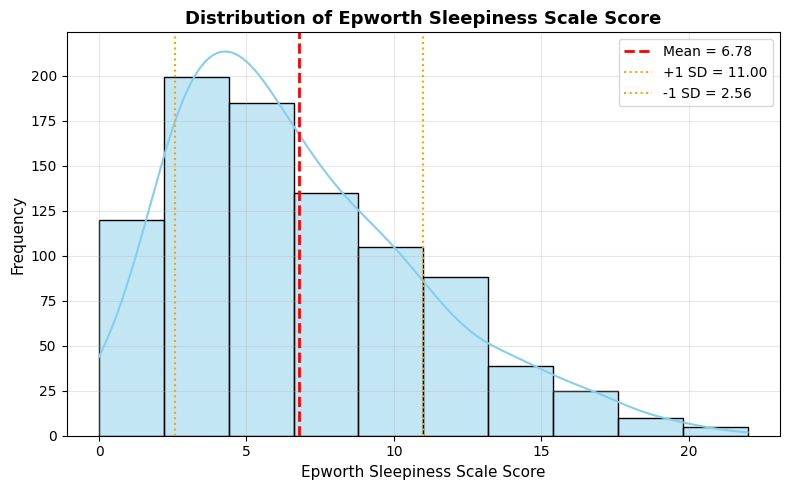

Statistical descriptors:
count    911.000000
mean       6.781559
std        4.222588
min        0.000000
25%        4.000000
50%        6.000000
75%        9.000000
max       22.000000
Name: Epworth Sleepiness Scale Score, dtype: float64


In [361]:
plot_hist_with_stats(sleep_data, 'Epworth Sleepiness Scale Score', bins=10)